<a href="https://colab.research.google.com/github/KimJong-sub/shrek/blob/main/2026_%EC%9C%A1%EA%B5%B0_AI%EC%86%8C%EC%96%91%EA%B5%90%EC%9C%A1_2%EC%9D%BC%EC%B0%A8_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎖️ 2026년 부대 맞춤형 AI·SW 소양교육
## 육군 직무보수교육 - **2일차 실습 노트북**

> **Ⅱ. 데이터 수집 및 전처리**
>  
> - 데이터 수집 개념 및 공공데이터 활용 (data.go.kr)
> - pandas를 이용한 CSV / Excel / JSON 데이터 읽기
> - DataFrame 탐색 (head, info, describe)
> - 데이터 선택·필터링 (loc, iloc, Boolean Indexing)
> - 결측값(Missing Value) 처리
> - 중복 제거·타입 변환·정규화
> - 이상치(Outlier) 탐지 및 처리
> - 데이터 그룹화 & 집계 (groupby)

---

### 📌 노트북 사용법
1. 각 셀을 순서대로 실행합니다. (`Shift + Enter` 또는 ▶ 버튼)
2. 💻 **실습 예제** 셀은 직접 실행하며 결과를 확인합니다.
3. 🔥 **실습문제** 셀에 직접 답안 코드를 작성해 보세요.
4. ✅ **정답 코드** 셀은 스스로 풀어본 뒤 확인하세요.

### 💡 핵심 원리: Garbage In, Garbage Out
> **"쓰레기가 들어오면, 쓰레기가 나온다"**  
> 데이터 분석의 **80%** 는 수집·전처리에 소요됩니다.  
> 수집 단계가 **분석 품질을 결정**합니다.

---

# 🛠️ Chapter 0. 환경 구성 및 샘플 데이터 준비

## 0-1. 주요 라이브러리 import
pandas, numpy, matplotlib은 Colab에 기본 설치되어 있습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 버전 확인
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"mpl     : {mpl.__version__}")

pandas  : 2.2.2
numpy   : 2.0.2
mpl     : 3.10.0


## 0-2. 한글 폰트 설정 (Colab 그래프 한글 깨짐 방지)

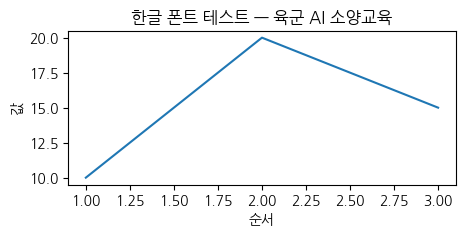

✅ 한글 폰트 설정 완료


In [2]:
# 나눔고딕 폰트 설치
!apt-get install -qq fonts-nanum > /dev/null 2>&1

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

# 테스트
plt.figure(figsize=(5, 2))
plt.title("한글 폰트 테스트 — 육군 AI 소양교육")
plt.plot([1, 2, 3], [10, 20, 15])
plt.xlabel("순서")
plt.ylabel("값")
plt.show()
print("✅ 한글 폰트 설정 완료")

## 0-3. 실습용 샘플 데이터 생성

외부 파일이 없어도 실습할 수 있도록, **부대원 인사/훈련 데이터** 를 Colab 환경에 직접 만듭니다.

- 의도적으로 **결측값(NaN), 중복 행, 이상치** 를 일부 포함시켰습니다.

In [3]:
import pandas as pd
import numpy as np

# 재현 가능한 난수
np.random.seed(42)

# 부대원 샘플 데이터
data = {
    "이름":     ["김철수", "이영희", "박민준", "최수진", "정태양",
               "한소희", "윤도현", "강민아", "송지훈", "임서연",
               "오현우", "배유진", "신동욱", "조은비", "문재혁",
               "한소희", "이수민", "박지성", "권나라", "최우식"],
    "부서":     ["행정과", "보급과", "통신과", "행정과", "보급과",
               "통신과", "행정과", "보급과", "통신과", "행정과",
               "보급과", "통신과", "행정과", "보급과", "통신과",
               "통신과", "행정과", "보급과", "행정과", "통신과"],
    "계급":     ["상병", "병장", "이병", "일병", "상병",
               "병장", "이병", "일병", "상병", "병장",
               "이병", "일병", "상병", "병장", "이병",
               "병장", "상병", "일병", "이병", "병장"],
    "입사연도": [2019, 2021, 2020, 2018, 2019,
               2022, 2023, 2021, 2020, 2018,
               2023, 2022, 2019, 2018, 2023,
               2022, 2020, 2021, 2023, 2018],
    "급여":    [420, 380, np.nan, 450, 410,
               390, 250, 350, 430, 470,
               260, 340, 420, 480, 255,
               390, 415, 355, np.nan, 475],
    "훈련점수": [85.2, 92.3, 78.5, 95.1, 88.0,
                np.nan, 72.1, 80.5, 91.2, 87.8,
                75.0, 82.4, 89.6, 94.3, 9999,    # 9999는 이상치
                92.3, 86.7, 79.2, 70.5, 93.1],
    "출석률":   [95.2, 88.7, 72.1, 91.5, 94.8,
                83.2, 78.9, 85.4, 90.1, 96.3,
                75.5, 81.7, 89.4, 97.2, 68.5,
                88.7, 92.3, 84.6, np.nan, 95.7],
    "입대일":   ["2019-03-01", "2021-06-15", "2020-09-10", "2018-04-20", "2019-07-05",
               "2022-02-28", "2023-05-12", "2021-11-03", "2020-08-17", "2018-10-25",
               "2023-01-09", "2022-07-14", "2019-12-22", "2018-05-30", "2023-03-18",
               "2022-02-28", "2020-04-05", "2021-09-19", "2023-06-24", "2018-11-08"]
}

df_original = pd.DataFrame(data)

# CSV로 저장하여 이후 실습에서 파일 읽기 연습에도 사용
df_original.to_csv('/content/soldiers.csv', index=False, encoding='utf-8-sig')
df_original.to_excel('/content/soldiers.xlsx', index=False)

print(f"✅ 샘플 데이터 생성 완료: {df_original.shape[0]}행 × {df_original.shape[1]}열")
print(f"   저장 위치: /content/soldiers.csv, /content/soldiers.xlsx")
df_original.head()

✅ 샘플 데이터 생성 완료: 20행 × 8열
   저장 위치: /content/soldiers.csv, /content/soldiers.xlsx


,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10
3,최수진,행정과,일병,2018,450.0,95.1,91.5,2018-04-20
4,정태양,보급과,상병,2019,410.0,88.0,94.8,2019-07-05


---
# 📥 Chapter 1. 데이터 수집 (Data Collection)

## 1-1. 데이터 수집이란?
> **분석 목적에 맞는 데이터를 찾고 불러오는 과정**  
> 데이터 분석의 첫 단계이자 가장 중요한 단계입니다.

### 5가지 주요 데이터 수집 방법

| 방법 | 도구 | 특징 |
|---|---|---|
| 🏛 **공공 데이터포털** | data.go.kr | 정부·지자체 무료 제공 |
| 📁 **파일 직접 읽기** | pandas | CSV, Excel, JSON 로컬 파일 |
| 🌐 **웹 스크래핑** | requests + BeautifulSoup | HTML 파싱 |
| 🔌 **API 호출** | requests | REST API, JSON 수신 |
| 🗄 **데이터베이스** | pandas.read_sql() | SQL 쿼리 |

## 1-2. 공공데이터포털 활용 절차
1. **data.go.kr** 회원가입·로그인
2. 원하는 데이터 검색 (예: 날씨, 인구, 교통)
3. 오픈API → 활용신청 → 즉시 승인
4. 마이페이지에서 **API 인증키(서비스키)** 확인

💡 군 관련 활용 가능 공공 데이터 예시:
- 기상청 날씨 예보
- 행정안전부 지역 정보
- 통계청 인구 데이터
- 보건복지부 의료기관
- 교통 CCTV 정보

## 1-3. API 호출 코드 구조 (참고)

아래는 **일반적인 공공 API 호출 패턴**입니다. 실제 실행하려면 본인의 인증키가 필요하므로, 코드 구조만 익혀두세요.

In [4]:
# ⚠️ 이 셀은 '구조 학습용'입니다. 실제 API 키가 없으면 실행되지 않습니다.

import requests
import pandas as pd

# 공공데이터 API 설정 (예시)
# KEY = 'ff39b298bc5a715558495da9e751559e'
# URL = 'http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst'
#
# params = {
#     'serviceKey': KEY,
#     'numOfRows': 100,
#     'pageNo': 1,
#     'dataType': 'JSON',
#     'base_date': '20260428',
#     'base_time': '0600',
#     'nx': 60, 'ny': 127   # 좌표
# }
#
# r = requests.get(URL, params=params)
# data = r.json()
# df = pd.DataFrame(data['response']['body']['items']['item'])
# df.head()

print("👆 실제 실행하려면 주석 해제 후 본인의 API 인증키를 입력하세요.")
print("   data.go.kr 회원가입 → 데이터 검색 → 활용신청 → 인증키 발급")

👆 실제 실행하려면 주석 해제 후 본인의 API 인증키를 입력하세요.
   data.go.kr 회원가입 → 데이터 검색 → 활용신청 → 인증키 발급


In [5]:
# =========================================
# 공공데이터 API를 활용한 영화 순위(박스오피스) 조회
# Google Colab용 Python 코드
# =========================================

# 설치가 필요한 경우 (보통 requests는 기본 설치됨)
# !pip install requests pandas

import requests
import pandas as pd
from datetime import datetime, timedelta

# -----------------------------------------
# 1. 영화진흥위원회(KOBIS) API Key 입력
# 공공데이터포털 또는 KOBIS 사이트에서 발급받은 인증키 입력
# -----------------------------------------
api_key = "ff39b298bc5a715558495da9e751559e"

# -----------------------------------------
# 2. 조회 날짜 설정
# (KOBIS는 보통 전날 박스오피스 기준)
# -----------------------------------------
target_date = (datetime.now() - timedelta(days=1)).strftime("%Y%m%d")

print(f"조회 날짜: {target_date}")

# -----------------------------------------
# 3. API URL 설정
# 일별 박스오피스 조회 API
# -----------------------------------------
url = "http://kobis.or.kr/kobisopenapi/webservice/rest/boxoffice/searchDailyBoxOfficeList.json"

params = {
    "key": api_key,
    "targetDt": target_date
}

# -----------------------------------------
# 4. API 요청
# -----------------------------------------
response = requests.get(url, params=params)

# 응답 확인
if response.status_code == 200:
    data = response.json()

    # -----------------------------------------
    # 5. 영화 순위 데이터 추출
    # -----------------------------------------
    movie_list = data["boxOfficeResult"]["dailyBoxOfficeList"]

    result = []

    for movie in movie_list:
        result.append({
            "순위": movie["rank"],
            "영화명": movie["movieNm"],
            "개봉일": movie["openDt"],
            "당일 관객수": movie["audiCnt"],
            "누적 관객수": movie["audiAcc"],
            "매출액": movie["salesAmt"]
        })

    # -----------------------------------------
    # 6. 데이터프레임 생성
    # -----------------------------------------
    df = pd.DataFrame(result)

    # -----------------------------------------
    # 7. 결과 출력
    # -----------------------------------------
    print("\n===== 오늘의 영화 순위 =====")
    display(df)

else:
    print("API 요청 실패")
    print("상태 코드:", response.status_code)

조회 날짜: 20260427

===== 오늘의 영화 순위 =====


,순위,영화명,개봉일,당일 관객수,누적 관객수,매출액
0,1,살목지,2026-04-08,41902,2025660,432784450
1,2,짱구,2026-04-22,15630,179528,151815590
2,3,프로젝트 헤일메리,2026-03-18,15612,2506504,177733770
3,4,왕과 사는 남자,2026-02-04,10114,16716939,97179210
4,5,란 12.3,2026-04-22,7279,140927,71385200
5,6,내 이름은,2026-04-15,4074,165682,36130300
6,7,리 크로닌의 미이라,2026-04-22,2758,30945,29366870
7,8,기동전사 건담: 섬광의 하사웨이 키르케의 마녀,2026-04-22,1329,19744,19936000
8,9,악마는 프라다를 입는다 2,2026-04-29,1001,1001,9009000
9,10,마녀배달부 키키,2007-11-22,949,116644,8928950


In [6]:
# =========================================
# 공공데이터 API를 활용한 유성구 주유소 최저가 순위 조회
# Google Colab용 Python 코드
# (오피넷 / 한국석유공사 유가정보 API 활용)
# =========================================

# 필요 라이브러리
# !pip install requests pandas lxml

import requests
import pandas as pd
import xml.etree.ElementTree as ET

# -----------------------------------------
# 1. 오피넷(Open API) 인증키 입력
# 공공데이터포털 또는 오피넷에서 발급받은 API Key 입력
# -----------------------------------------
api_key = "	F260428227"

# -----------------------------------------
# 2. 유성구 코드 설정
# 대전광역시 유성구
#
# SIGUNCD 예시:
# 대전 유성구 코드 사용
# (실제 수업에서는 교수님 제공 코드 사용 가능)
# -----------------------------------------
area_code = "30140"   # 대전 유성구 행정구역 코드 예시

# -----------------------------------------
# 3. 조회할 유종 선택
#
# B027 : 휘발유
# D047 : 경유
# C004 : 고급휘발유
# K015 : LPG
# -----------------------------------------
prodcd = "B027"   # 휘발유 기준

# -----------------------------------------
# 4. API URL 설정
# 지역별 최저가 주유소 조회
# -----------------------------------------
url = "http://www.opinet.co.kr/api/lowTop10.do"

params = {
    "out": "xml",
    "code": api_key,
    "area": area_code,
    "prodcd": prodcd
}

# -----------------------------------------
# 5. API 요청
# -----------------------------------------
response = requests.get(url, params=params)

if response.status_code == 200:
    root = ET.fromstring(response.content)

    result = []

    # -----------------------------------------
    # 6. XML 데이터 파싱
    # -----------------------------------------
    for oil in root.findall(".//OIL"):
        result.append({
            "주유소명": oil.findtext("OS_NM"),
            "상표": oil.findtext("POLL_DIV_CD"),
            "주소": oil.findtext("NEW_ADR"),
            "가격(원)": oil.findtext("PRICE"),
            "셀프주유소": oil.findtext("SELF_YN")
        })

    # -----------------------------------------
    # 7. 데이터프레임 생성
    # -----------------------------------------
    df = pd.DataFrame(result)

    # 가격 숫자형 변환
    df["가격(원)"] = pd.to_numeric(df["가격(원)"], errors="coerce")

    # 가격 오름차순 정렬
    df = df.sort_values("가격(원)")

    # 순위 추가
    df.insert(0, "순위", range(1, len(df) + 1))

    # -----------------------------------------
    # 8. 결과 출력
    # -----------------------------------------
    print("===== 유성구 주유소 휘발유 최저가 순위 =====")
    display(df)

else:
    print("API 요청 실패")
    print("상태 코드:", response.status_code)

KeyError: '가격(원)'

In [7]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET

# ---------------------------------
# API Key 입력
# ---------------------------------
api_key = "F260428227"

# ---------------------------------
# 유성구 지역 코드
# ---------------------------------
area_code = "30140"

# 휘발유
prodcd = "B027"

# ---------------------------------
# API URL
# ---------------------------------
url = "http://www.opinet.co.kr/api/lowTop10.do"

params = {
    "out": "xml",
    "code": api_key,
    "area": area_code,
    "prodcd": prodcd
}

response = requests.get(url, params=params)

print("상태코드:", response.status_code)
print("응답 확인 ↓↓↓")
print(response.text[:1000])  # 앞부분만 출력

if response.status_code == 200:
    root = ET.fromstring(response.content)

    result = []

    for oil in root.findall(".//OIL"):
        station_name = oil.findtext("OS_NM")
        brand = oil.findtext("POLL_DIV_CD")
        address = oil.findtext("NEW_ADR")
        price = oil.findtext("PRICE")
        self_yn = oil.findtext("SELF_YN")

        result.append({
            "주유소명": station_name,
            "상표": brand,
            "주소": address,
            "가격": price,
            "셀프여부": self_yn
        })

    # 데이터프레임 생성
    df = pd.DataFrame(result)

    # 데이터가 있는지 확인
    if not df.empty:
        print("\n컬럼 확인:")
        print(df.columns)

        df["가격"] = pd.to_numeric(df["가격"], errors="coerce")
        df = df.sort_values("가격")

        df.insert(0, "순위", range(1, len(df) + 1))

        print("\n===== 유성구 주유소 최저가 순위 =====")
        display(df)

    else:
        print("조회된 주유소 데이터가 없습니다.")

else:
    print("API 요청 실패")

상태코드: 200
응답 확인 ↓↓↓
<?xml version="1.0" encoding="UTF-8"?>                           
           
 
<RESULT>                                                         
                                             
</RESULT>
조회된 주유소 데이터가 없습니다.


In [8]:
# =========================================
# 공공데이터 API를 활용한 대전 현재 날씨 조회
# Google Colab용 Python 코드
# (기상청 단기예보 API 활용)
# =========================================

# 필요 라이브러리
# !pip install requests pandas

import requests
import pandas as pd
from datetime import datetime

# -----------------------------------------
# 1. 기상청 API 인증키 입력
# (공공데이터포털에서 발급받은 Service Key)
# -----------------------------------------
service_key = "e7eba533bc9a7b9487df4b77093e4332c42aa5bf0eeb316dac315ab39a1b7315"

# -----------------------------------------
# 2. 대전 지역 격자 좌표
#
# 대전광역시 기준 예시
# nx = 67
# ny = 100
#
# (지역마다 다름)
# -----------------------------------------
nx = 67
ny = 100

# -----------------------------------------
# 3. base_date, base_time 설정
#
# 단기예보 발표시간:
# 0200, 0500, 0800, 1100,
# 1400, 1700, 2000, 2300
#
# 보통 가장 최근 발표시간 사용
# -----------------------------------------
now = datetime.now()

base_date = now.strftime("%Y%m%d")
current_hour = now.hour

if current_hour < 2:
    base_time = "2300"
elif current_hour < 5:
    base_time = "0200"
elif current_hour < 8:
    base_time = "0500"
elif current_hour < 11:
    base_time = "0800"
elif current_hour < 14:
    base_time = "1100"
elif current_hour < 17:
    base_time = "1400"
elif current_hour < 20:
    base_time = "1700"
elif current_hour < 23:
    base_time = "2000"
else:
    base_time = "2300"

print("조회 날짜:", base_date)
print("발표 시각:", base_time)

# -----------------------------------------
# 4. API URL
# -----------------------------------------
url = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst"

params = {
    "serviceKey": service_key,
    "pageNo": "1",
    "numOfRows": "1000",
    "dataType": "JSON",
    "base_date": base_date,
    "base_time": base_time,
    "nx": nx,
    "ny": ny
}

# -----------------------------------------
# 5. API 요청
# -----------------------------------------
response = requests.get(url, params=params)

print("상태 코드:", response.status_code)

if response.status_code == 200:
    data = response.json()

    try:
        items = data["response"]["body"]["items"]["item"]

        result = []

        for item in items:
            # 오늘 날짜 + 가장 가까운 시간만 보고 싶으면 필터 가능
            if item["fcstDate"] == base_date:
                result.append({
                    "예보시간": item["fcstTime"],
                    "항목": item["category"],
                    "값": item["fcstValue"]
                })

        df = pd.DataFrame(result)

        print("\n===== 대전 오늘 날씨 예보 =====")
        display(df)

    except Exception as e:
        print("데이터 파싱 오류")
        print(e)
        print(data)

else:
    print("API 요청 실패")
    print(response.text)

조회 날짜: 20260428
발표 시각: 2300
상태 코드: 401
API 요청 실패
Unauthorized



In [16]:

import requests
import pandas as pd

service_key = "e7eba533bc9a7b9487df4b77093e4332c42aa5bf0eeb316dac315ab39a1b7315"

url = "https://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst"

params = {
    "serviceKey": service_key,
    "pageNo": "1",
    "numOfRows": "100",
    "dataType": "JSON",
    "base_date": "20260428",
    "base_time": "0500",
    "nx": "67",
    "ny": "100"
}

response = requests.get(url, params=params)
data = response.json()

items = data["response"]["body"]["items"]["item"]

weather = {}

for item in items:
    # 가장 가까운 시간 (0600 기준)
    if item["fcstTime"] == "0600":
        category = item["category"]
        value = item["fcstValue"]

        if category == "TMP":
            weather["기온"] = value + "℃"

        elif category == "SKY":
            sky_dict = {
                "1": "맑음",
                "3": "구름많음",
                "4": "흐림"
            }
            weather["하늘상태"] = sky_dict.get(value, value)

        elif category == "PTY":
            pty_dict = {
                "0": "없음",
                "1": "비",
                "2": "비/눈",
                "3": "눈",
                "4": "소나기"
            }
            weather["강수형태"] = pty_dict.get(value, value)

        elif category == "POP":
            weather["강수확률"] = value + "%"

        elif category == "WSD":
            weather["풍속"] = value + "m/s"

        elif category == "PCP":
            weather["강수량"] = value

df = pd.DataFrame(weather.items(), columns=["항목", "값"])

print("===== 대전 현재 날씨 =====")
display(df)

===== 대전 현재 날씨 =====


,항목,값
0,기온,12℃
1,풍속,3.5m/s
2,하늘상태,흐림
3,강수형태,없음
4,강수확률,30%
5,강수량,강수없음


In [71]:
#1. 라이브러리 설치 및 import ==========
!pip install requests --quiet

import requests
import json
from datetime import datetime, timedelta
from collections import defaultdict

#2. 설정값 입력 ==========
# ✅ 공공데이터포털에서 발급받은 서비스키(Decoding)를 입력하세요
API_KEY = "e7eba533bc9a7b9487df4b77093e4332c42aa5bf0eeb316dac315ab39a1b7315"  # <-- 수정 필요

# 대전광역시 격자 좌표 (기상청 단기예보 기준)
NX = 67
NY = 100
LOCATION_NAME = "대전광역시"

# 기상청 단기예보 API URL
FORECAST_URL = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst"
ULTRAST_URL  = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getUltraSrtFcst"
REALTIME_URL = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getUltraSrtNcst"
WARNING_URL  = "http://apis.data.go.kr/1360000/WthrWrnInfoService/getWthrWrnMsg"

print("✅ 설정 완료")

#3. 공통함수 정의 ==========
def get_base_time():
    """단기예보 발표 기준시각 계산 (3시간 단위: 0200, 0500, 0800, 1100, 1400, 1700, 2000, 2300)"""
    now = datetime.now()
    base_times = [2, 5, 8, 11, 14, 17, 20, 23]
    hour = now.hour
    adjusted_hour = hour if now.minute >= 10 else hour - 1
    base_hour = max([t for t in base_times if t <= adjusted_hour], default=23)
    if adjusted_hour < 2:
        base_hour = 23
        now = now - timedelta(days=1)
    return now.strftime("%Y%m%d"), f"{base_hour:02d}00"

def get_ultrast_base_time():
    """초단기예보 기준시각 (매시간 30분 발표)"""
    now = datetime.now()
    if now.minute < 30:
        now = now - timedelta(hours=1)
    return now.strftime("%Y%m%d"), now.strftime("%H") + "30"

def call_api(url, params):
    """API 호출 공통 함수"""
    try:
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        if data["response"]["header"]["resultCode"] == "00":
            return data["response"]["body"]["items"]["item"]
        else:
            print(f"[API 오류] {data['response']['header']['resultMsg']}")
            return None
    except Exception as e:
        print(f"[연결 오류] {e}")
        return None

def sky_code(val):
    return {"1":"☀️ 맑음", "3":"⛅ 구름많음", "4":"☁️ 흐림"}.get(str(val), f"코드:{val}")

def pty_code(val):
    return {"0":"없음", "1":"🌧️ 비", "2":"🌨️ 비/눈", "3":"❄️ 눈", "4":"🌦️ 소나기"}.get(str(val), f"코드:{val}")

def wind_dir(deg):
    dirs = ["북","북북동","북동","동북동","동","동남동","남동","남남동",
            "남","남남서","남서","서남서","서","서북서","북서","북북서"]
    try:
        return dirs[round(float(deg) / 22.5) % 16]
    except:
        return "불명"

def fire_risk(temp, humidity, wind):
    """간이 화재위험 판정 (기온·습도·풍속 기반)"""
    try:
        t, h, w = float(temp), float(humidity), float(wind)
        score = 0
        if t > 25: score += 2
        elif t > 15: score += 1
        if h < 30: score += 3
        elif h < 50: score += 2
        elif h < 65: score += 1
        if w > 9: score += 3
        elif w > 5: score += 2
        elif w > 3: score += 1
        if score >= 6: return "🔴 매우높음", "화기 취급 전면 금지, 소방시설 즉시 점검"
        if score >= 4: return "🟠 높음",     "야외 화기 사용 자제, 소화기 비치 확인"
        if score >= 2: return "🟡 보통",     "일반적 화기 주의 사항 준수"
        return "🟢 낮음", "이상 없음"
    except:
        return "⚪ 산출불가", "-"

def visibility_from_weather(sky, pty, wind):
    """기상 정보 기반 가시거리 추정"""
    try:
        w = float(wind)
    except:
        w = 0
    if str(pty) in ["1","4"]:  return "🌧️ 약 1~3 km (우천)"
    if str(pty) in ["2","3"]:  return "🌨️ 약 0.5~2 km (눈)"
    if str(sky) == "4" and w > 5: return "🌫️ 약 3~5 km (흐림+강풍)"
    if str(sky) == "4":           return "☁️ 약 5~8 km (흐림)"
    if str(sky) == "3":           return "⛅ 약 8~15 km (구름많음)"
    return "☀️ 10 km 이상 (양호)"

def accident_measures(pty, wind, temp):
    """기상 조건별 사고 예방 조치사항 자동 생성"""
    measures = []
    try:
        w = float(wind)
        t = float(temp)
    except:
        w, t = 0, 15

    if str(pty) in ["1","4"]:
        measures += ["우천 시 도로 결빙 및 낙상 위험 증가 → 차량 서행 및 도보 이동 시 주의",
                     "우의 및 방수장비 착용, 야외 훈련 일정 재검토"]
    if str(pty) in ["2","3"]:
        measures += ["강설 시 제설 작업 즉시 실시, 낙상·교통사고 주의",
                     "동파 위험 시설(수도관·차량) 사전 점검"]
    if w >= 9:
        measures += ["강풍 주의보 수준 → 고소작업 및 천막·구조물 고정 여부 점검",
                     "낙하물 위험 구역 접근 통제"]
    elif w >= 5:
        measures += ["바람 강함 → 경량 장비 고정 및 외부 훈련 시 방풍 조치"]
    if t <= 0:
        measures += ["영하 기온 → 동상·저체온증 예방, 내한 장비 착용 필수",
                     "차량 시동 예열 및 결빙 노면 확인"]
    elif t <= 5:
        measures += ["저온 주의 → 방한복 착용 권고, 외부 작업 시 체온 유지"]
    if t >= 33:
        measures += ["폭염 주의보 수준 → 충분한 수분 보충, 야외 훈련 시간 조정",
                     "온열질환 의심 증상 발생 시 즉시 보고 조치"]
    elif t >= 28:
        measures += ["고온 주의 → 야외 작업 전 열 스트레스 점검, 휴식 시간 확보"]
    if not measures:
        measures = ["현재 특이 기상 위험 없음 — 일반 안전 수칙 준수"]
    return measures

DAY_KR = ["월","화","수","목","금","토","일"]

print("✅ 함수 정의 완료")

#4. API 데이터 수집 ==========
today      = datetime.now()
today_str  = today.strftime("%Y%m%d")
base_date, base_time = get_base_time()
ust_date,  ust_time  = get_ultrast_base_time()

print(f"📡 단기예보 기준: {base_date} {base_time}")
print(f"📡 초단기예보 기준: {ust_date} {ust_time}")

# 단기예보 (3일치)
fcst_items = call_api(FORECAST_URL, {
    "serviceKey": API_KEY,
    "numOfRows": 1000,
    "pageNo": 1,
    "dataType": "JSON",
    "base_date": base_date,
    "base_time": base_time,
    "nx": NX,
    "ny": NY
})

# 초단기실황 (현재 기상)
now_items = call_api(REALTIME_URL, {
    "serviceKey": API_KEY,
    "numOfRows": 100,
    "pageNo": 1,
    "dataType": "JSON",
    "base_date": today_str,
    "base_time": datetime.now().strftime("%H") + "00",
    "nx": NX,
    "ny": NY
})

# 기상 특보
warn_items = call_api(WARNING_URL, {
    "serviceKey": API_KEY,
    "numOfRows": 10,
    "pageNo": 1,
    "dataType": "JSON",
    "stnId": "133",    # 대전 기상관서 코드
    "fromTmFc": (today - timedelta(days=1)).strftime("%Y%m%d") + "0000",
    "toTmFc":   today.strftime("%Y%m%d") + "2359",
})

print("\n✅ API 수집 완료")


# 5. 데이터 파싱  ==========

# 현재 실황 파싱
now_data = {}
if now_items:
    for it in now_items:
        now_data[it["category"]] = it["obsrValue"]

cur_temp  = now_data.get("T1H", "N/A")   # 기온
cur_hum   = now_data.get("REH", "N/A")   # 습도
cur_wind  = now_data.get("WSD", "N/A")   # 풍속
cur_wdir  = now_data.get("VEC", "N/A")   # 풍향
cur_pty   = now_data.get("PTY", "0")     # 강수형태
cur_rn1   = now_data.get("RN1", "0")     # 1시간강수량

# 단기예보 파싱 → 날짜·시간별 딕셔너리
fcst_by_dt = defaultdict(dict)
if fcst_items:
    for it in fcst_items:
        key = f"{it['fcstDate']}_{it['fcstTime']}"
        fcst_by_dt[key][it["category"]] = it["fcstValue"]

# 날짜별 집계 (일 최고·최저기온, 대표 하늘상태)
daily = defaultdict(lambda: {"TMX":None,"TMN":None,"SKY":[],"PTY":[],"POP":[]})
for key, vals in fcst_by_dt.items():
    d = key[:8]
    if "TMX" in vals: daily[d]["TMX"] = vals["TMX"]
    if "TMN" in vals: daily[d]["TMN"] = vals["TMN"]
    if "SKY" in vals: daily[d]["SKY"].append(vals["SKY"])
    if "PTY" in vals: daily[d]["PTY"].append(vals["PTY"])
    if "POP" in vals: daily[d]["POP"].append(int(vals["POP"]))

# 오늘 대표 날씨
from collections import Counter
today_sky = today_pty = today_pop = "N/A"
today_tmx = daily[today_str].get("TMX", "N/A")
today_tmn = daily[today_str].get("TMN", "N/A")
if daily[today_str]["SKY"]:
    today_sky = Counter(daily[today_str]["SKY"]).most_common(1)[0][0]
if daily[today_str]["PTY"]:
    today_pty = Counter(daily[today_str]["PTY"]).most_common(1)[0][0]
if daily[today_str]["POP"]:
    today_pop = max(daily[today_str]["POP"])

# 내일 대표 날씨
tomorrow = (today + timedelta(days=1)).strftime("%Y%m%d")
tmr_sky = tmr_pty = tmr_pop = "N/A"
tmr_tmx = daily[tomorrow].get("TMX", "N/A")
tmr_tmn = daily[tomorrow].get("TMN", "N/A")
if daily[tomorrow]["SKY"]:
    tmr_sky = Counter(daily[tomorrow]["SKY"]).most_common(1)[0][0]
if daily[tomorrow]["PTY"]:
    tmr_pty = Counter(daily[tomorrow]["PTY"]).most_common(1)[0][0]
if daily[tomorrow]["POP"]:
    tmr_pop = max(daily[tomorrow]["POP"])

# 시간대별 기온 (오늘)
hour_temps = {}
for key, vals in fcst_by_dt.items():
    if key[:8] == today_str and "TMP" in vals:
        hour_temps[key[9:]] = vals["TMP"]

# 화재위험·가시거리·조치사항
fire_level, fire_action = fire_risk(cur_temp, cur_hum, cur_wind)
vis_str  = visibility_from_weather(today_sky, cur_pty, cur_wind)
measures = accident_measures(cur_pty, cur_wind, cur_temp)

print("✅ 파싱 완료")


# 6. 브리핑 출력  ==========

LINE  = "═" * 56
LINE2 = "─" * 56

print(LINE)
print(f"  🪖  기 상 현 황   브 리 핑  🪖")
print(f"  📍 지역 : {LOCATION_NAME}")
print(f"  🕐 기준 : {today.strftime('%Y년 %m월 %d일 (%a) %H:%M')} 현재")
print(LINE)

# [1] 오늘의 날씨
print("\n[1] 오늘의 날씨")
print(LINE2)
print(f"  • 하늘 상태   : {sky_code(today_sky)}")
print(f"  • 강수 형태   : {pty_code(today_pty)}")
print(f"  • 강수 확률   : {today_pop}%")
print(f"  • 최고 기온   : {today_tmx}°C")
print(f"  • 최저 기온   : {today_tmn}°C")
print(f"  • 현재 습도   : {cur_hum}%")
print(f"  • 현재 풍속   : {cur_wind} m/s  ({wind_dir(cur_wdir)}풍)")
if str(cur_rn1) not in ["0","강수없음","N/A"]:
    print(f"  • 1시간 강수량 : {cur_rn1} mm")

# [2] 내일 기상 예측
print("\n[2] 내일 기상 예측")
print(LINE2)
print(f"  • 하늘 상태   : {sky_code(tmr_sky)}")
print(f"  • 강수 형태   : {pty_code(tmr_pty)}")
print(f"  • 강수 확률   : {tmr_pop}%")
print(f"  • 최고 기온   : {tmr_tmx}°C")
print(f"  • 최저 기온   : {tmr_tmn}°C")

# [3] 현재 기온
print("\n[3] 현재 기온")
print(LINE2)
print(f"  • 현재 기온   : {cur_temp}°C")
try:
    chill = float(cur_temp) - float(cur_wind) * 0.7
    print(f"  • 체감 기온   : {chill:.1f}°C  (풍속 보정 적용)")
except:
    pass
print(f"  • 일최고 예상 : {today_tmx}°C  /  일최저 예상 : {today_tmn}°C")

# [4] 기온 변화
print("\n[4] 기온 변화 (시간대별, 오늘)")
print(LINE2)
slots = ["0000","0300","0600","0900","1200","1500","1800","2100"]
found = False
for sl in slots:
    if sl in hour_temps:
        label = f"{int(sl[:2]):02d}시"
        bar_len = max(0, int(float(hour_temps[sl])) + 10)
        bar = "▓" * min(bar_len, 40)
        print(f"  {label}  {hour_temps[sl]:>5}°C  {bar}")
        found = True
if not found:
    print("  (단기예보 데이터 없음)")

# [5] 화재 위험
print("\n[5] 화재 위험")
print(LINE2)
print(f"  • 위험 수준   : {fire_level}")
print(f"  • 판정 근거   : 기온 {cur_temp}°C / 습도 {cur_hum}% / 풍속 {cur_wind} m/s")
print(f"  • 조치 사항   : {fire_action}")

# [6] 가시거리
print("\n[6] 가시거리")
print(LINE2)
print(f"  • 추정 가시거리 : {vis_str}")
print(f"  • 판정 기준     : 하늘상태 {sky_code(today_sky)} / 강수형태 {pty_code(today_pty)} / 풍속 {cur_wind} m/s")

# [7] 사고 예방 조치사항
print("\n[7] 사고 발생 예방을 위한 조치사항")
print(LINE2)
for i, m in enumerate(measures, 1):
    print(f"  {i}. {m}")

# [8] 주간 요일별 예상 날씨
print("\n[8] 주간 요일별 예상 날씨")
print(LINE2)
print(f"  {'날짜':<12} {'요일':<4} {'하늘':<12} {'강수확률':>6} {'최고':>6} {'최저':>6}")
print(f"  {'─'*12} {'─'*4} {'─'*12} {'─'*6} {'─'*6} {'─'*6}")
for i in range(7):
    d  = today + timedelta(days=i)
    ds = d.strftime("%Y%m%d")
    d_label = d.strftime("%m/%d")
    dow = DAY_KR[d.weekday()]
    if ds not in daily:
        print(f"  {d_label:<12} {dow+'요일':<4} {'─':<12} {'─':>6} {'─':>6} {'─':>6}")
        continue
    dd = daily[ds]
    sky_rep = sky_code(Counter(dd["SKY"]).most_common(1)[0][0]) if dd["SKY"] else "─"
    pty_rep = pty_code(Counter(dd["PTY"]).most_common(1)[0][0]) if dd["PTY"] else ""
    pop_rep = f"{max(dd['POP'])}%" if dd["POP"] else "─"
    tmx_rep = f"{dd['TMX']}°C"    if dd["TMX"] else "─"
    tmn_rep = f"{dd['TMN']}°C"    if dd["TMN"] else "─"
    sky_disp = (sky_rep + " " + pty_rep).strip()
    tag = "← 오늘" if i == 0 else ("← 내일" if i == 1 else "")
    print(f"  {d_label:<12} {dow+'요일':<4} {sky_disp:<14} {pop_rep:>6} {tmx_rep:>6} {tmn_rep:>6}  {tag}")

# [9] 기상 특보
print("\n[9] 기상 특보")
print(LINE2)
if warn_items:
    for w in warn_items:
        print(f"  ⚠️  [{w.get('wrnId','-')}] {w.get('title','내용 없음')}")
        print(f"      발표: {w.get('tmFc','-')}  /  지역: {w.get('stnId','-')}")
        print(f"      내용: {str(w.get('warn',''))[:120]}...")
        print()
else:
    print("  ✅ 현재 대전 지역 발효 중인 기상 특보 없음")

print()
print(LINE)
print(f"  ※ 본 브리핑은 기상청 공공데이터를 기반으로 자동 생성됩니다.")
print(f"  ※ 출처 : 기상청 단기예보 서비스 (data.go.kr)")
print(f"  ※ 작성 : {today.strftime('%Y-%m-%d %H:%M')} 자동 생성")
print(LINE)



✅ 설정 완료
✅ 함수 정의 완료
📡 단기예보 기준: 20260428 0500
📡 초단기예보 기준: 20260428 0630
[연결 오류] 403 Client Error: Forbidden for url: http://apis.data.go.kr/1360000/WthrWrnInfoService/getWthrWrnMsg?serviceKey=e7eba533bc9a7b9487df4b77093e4332c42aa5bf0eeb316dac315ab39a1b7315&numOfRows=10&pageNo=1&dataType=JSON&stnId=133&fromTmFc=202604270000&toTmFc=202604282359

✅ API 수집 완료
✅ 파싱 완료
════════════════════════════════════════════════════════
  🪖  기 상 현 황   브 리 핑  🪖
  📍 지역 : 대전광역시
  🕐 기준 : 2026년 04월 28일 (Tue) 06:45 현재
════════════════════════════════════════════════════════

[1] 오늘의 날씨
────────────────────────────────────────────────────────
  • 하늘 상태   : ☁️ 흐림
  • 강수 형태   : 없음
  • 강수 확률   : 30%
  • 최고 기온   : 19.0°C
  • 최저 기온   : None°C
  • 현재 습도   : 74%
  • 현재 풍속   : 2.2 m/s  (남서풍)

[2] 내일 기상 예측
────────────────────────────────────────────────────────
  • 하늘 상태   : ☁️ 흐림
  • 강수 형태   : 없음
  • 강수 확률   : 30%
  • 최고 기온   : 20.0°C
  • 최저 기온   : 7.0°C

[3] 현재 기온
──────────────────────────────────────────────────────

In [72]:
#1. 라이브러리 설치 및 import ==========
!pip install requests --quiet

import requests
import json
from datetime import datetime, timedelta
from collections import defaultdict

#2. 설정값 입력 ==========
# ✅ 공공데이터포털에서 발급받은 서비스키(Decoding)를 입력하세요
API_KEY = "e7eba533bc9a7b9487df4b77093e4332c42aa5bf0eeb316dac315ab39a1b7315"  # <-- 수정 필요

# 대전광역시 격자 좌표 (기상청 단기예보 기준)
NX = 67
NY = 100
LOCATION_NAME = "대전광역시"

# 기상청 단기예보 API URL
FORECAST_URL = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst"
ULTRAST_URL  = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getUltraSrtFcst"
REALTIME_URL = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getUltraSrtNcst"
WARNING_URL  = "http://apis.data.go.kr/1360000/WthrWrnInfoService/getWthrWrnMsg"

print("✅ 설정 완료")

#3. 공통함수 정의 ==========
def get_base_time():
    """단기예보 발표 기준시각 계산 (3시간 단위: 0200, 0500, 0800, 1100, 1400, 1700, 2000, 2300)"""
    now = datetime.now()
    base_times = [2, 5, 8, 11, 14, 17, 20, 23]
    hour = now.hour
    adjusted_hour = hour if now.minute >= 10 else hour - 1
    base_hour = max([t for t in base_times if t <= adjusted_hour], default=23)
    if adjusted_hour < 2:
        base_hour = 23
        now = now - timedelta(days=1)
    return now.strftime("%Y%m%d"), f"{base_hour:02d}00"

def get_ultrast_base_time():
    """초단기예보 기준시각 (매시간 30분 발표)"""
    now = datetime.now()
    if now.minute < 30:
        now = now - timedelta(hours=1)
    return now.strftime("%Y%m%d"), now.strftime("%H") + "30"

def call_api(url, params):
    """API 호출 공통 함수"""
    try:
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        if data["response"]["header"]["resultCode"] == "00":
            return data["response"]["body"]["items"]["item"]
        else:
            print(f"[API 오류] {data['response']['header']['resultMsg']}")
            return None
    except Exception as e:
        print(f"[연결 오류] {e}")
        return None

def sky_code(val):
    return {"1":"☀️ 맑음", "3":"⛅ 구름많음", "4":"☁️ 흐림"}.get(str(val), f"코드:{val}")

def pty_code(val):
    return {"0":"없음", "1":"🌧️ 비", "2":"🌨️ 비/눈", "3":"❄️ 눈", "4":"🌦️ 소나기"}.get(str(val), f"코드:{val}")

def wind_dir(deg):
    dirs = ["북","북북동","북동","동북동","동","동남동","남동","남남동",
            "남","남남서","남서","서남서","서","서북서","북서","북북서"]
    try:
        return dirs[round(float(deg) / 22.5) % 16]
    except:
        return "불명"

def fire_risk(temp, humidity, wind):
    """간이 화재위험 판정 (기온·습도·풍속 기반)"""
    try:
        t, h, w = float(temp), float(humidity), float(wind)
        score = 0
        if t > 25: score += 2
        elif t > 15: score += 1
        if h < 30: score += 3
        elif h < 50: score += 2
        elif h < 65: score += 1
        if w > 9: score += 3
        elif w > 5: score += 2
        elif w > 3: score += 1
        if score >= 6: return "🔴 매우높음", "화기 취급 전면 금지, 소방시설 즉시 점검"
        if score >= 4: return "🟠 높음",     "야외 화기 사용 자제, 소화기 비치 확인"
        if score >= 2: return "🟡 보통",     "일반적 화기 주의 사항 준수"
        return "🟢 낮음", "이상 없음"
    except:
        return "⚪ 산출불가", "-"

def visibility_from_weather(sky, pty, wind):
    """기상 정보 기반 가시거리 추정"""
    try:
        w = float(wind)
    except:
        w = 0
    if str(pty) in ["1","4"]:  return "🌧️ 약 1~3 km (우천)"
    if str(pty) in ["2","3"]:  return "🌨️ 약 0.5~2 km (눈)"
    if str(sky) == "4" and w > 5: return "🌫️ 약 3~5 km (흐림+강풍)"
    if str(sky) == "4":           return "☁️ 약 5~8 km (흐림)"
    if str(sky) == "3":           return "⛅ 약 8~15 km (구름많음)"
    return "☀️ 10 km 이상 (양호)"

def accident_measures(pty, wind, temp):
    """기상 조건별 사고 예방 조치사항 자동 생성"""
    measures = []
    try:
        w = float(wind)
        t = float(temp)
    except:
        w, t = 0, 15

    if str(pty) in ["1","4"]:
        measures += ["우천 시 도로 결빙 및 낙상 위험 증가 → 차량 서행 및 도보 이동 시 주의",
                     "우의 및 방수장비 착용, 야외 훈련 일정 재검토"]
    if str(pty) in ["2","3"]:
        measures += ["강설 시 제설 작업 즉시 실시, 낙상·교통사고 주의",
                     "동파 위험 시설(수도관·차량) 사전 점검"]
    if w >= 9:
        measures += ["강풍 주의보 수준 → 고소작업 및 천막·구조물 고정 여부 점검",
                     "낙하물 위험 구역 접근 통제"]
    elif w >= 5:
        measures += ["바람 강함 → 경량 장비 고정 및 외부 훈련 시 방풍 조치"]
    if t <= 0:
        measures += ["영하 기온 → 동상·저체온증 예방, 내한 장비 착용 필수",
                     "차량 시동 예열 및 결빙 노면 확인"]
    elif t <= 5:
        measures += ["저온 주의 → 방한복 착용 권고, 외부 작업 시 체온 유지"]
    if t >= 33:
        measures += ["폭염 주의보 수준 → 충분한 수분 보충, 야외 훈련 시간 조정",
                     "온열질환 의심 증상 발생 시 즉시 보고 조치"]
    elif t >= 28:
        measures += ["고온 주의 → 야외 작업 전 열 스트레스 점검, 휴식 시간 확보"]
    if not measures:
        measures = ["현재 특이 기상 위험 없음 — 일반 안전 수칙 준수"]
    return measures

DAY_KR = ["월","화","수","목","금","토","일"]

print("✅ 함수 정의 완료")

#4. API 데이터 수집 ==========
today      = datetime.now()
today_str  = today.strftime("%Y%m%d")
base_date, base_time = get_base_time()
ust_date,  ust_time  = get_ultrast_base_time()

print(f"📡 단기예보 기준: {base_date} {base_time}")
print(f"📡 초단기예보 기준: {ust_date} {ust_time}")

# 단기예보 (3일치)
fcst_items = call_api(FORECAST_URL, {
    "serviceKey": API_KEY,
    "numOfRows": 1000,
    "pageNo": 1,
    "dataType": "JSON",
    "base_date": base_date,
    "base_time": base_time,
    "nx": NX,
    "ny": NY
})

# 초단기실황 (현재 기상)
now_items = call_api(REALTIME_URL, {
    "serviceKey": API_KEY,
    "numOfRows": 100,
    "pageNo": 1,
    "dataType": "JSON",
    "base_date": today_str,
    "base_time": datetime.now().strftime("%H") + "00",
    "nx": NX,
    "ny": NY
})

# ✅ 기상특보: 기상청 RSS 방식으로 대체 (별도 API 승인 불필요)
import xml.etree.ElementTree as ET

def get_weather_warning_rss(region_code="30"):
    """
    기상청 기상특보 RSS 파싱 (승인 없이 사용 가능)
    region_code: 30 = 충청남도·대전 권역
    기상청 RSS 지역코드 목록: https://www.weather.go.kr/w/pop/rss-guide.do
    """
    url = f"https://www.weather.go.kr/w/rss/dfs/hr1-forecast.do?zone={region_code}"
    # 특보 전용 RSS
    warn_url = "https://www.weather.go.kr/w/rss/warning.do"
    try:
        resp = requests.get(warn_url, timeout=10)
        resp.encoding = "utf-8"
        root = ET.fromstring(resp.text)
        items = []
        for item in root.iter("item"):
            title    = item.findtext("title", "").strip()
            desc     = item.findtext("description", "").strip()
            pub_date = item.findtext("pubDate", "").strip()
            # 대전 관련 항목만 필터링
            if "대전" in title or "대전" in desc or "충청" in title or "충청" in desc:
                items.append({"title": title, "desc": desc, "date": pub_date})
        return items
    except Exception as e:
        print(f"[특보 RSS 오류] {e}")
        return None

warn_items = get_weather_warning_rss()

print("\n✅ API 수집 완료")

# 5. 데이터 파싱  ==========

# 현재 실황 파싱
now_data = {}
if now_items:
    for it in now_items:
        now_data[it["category"]] = it["obsrValue"]

cur_temp  = now_data.get("T1H", "N/A")   # 기온
cur_hum   = now_data.get("REH", "N/A")   # 습도
cur_wind  = now_data.get("WSD", "N/A")   # 풍속
cur_wdir  = now_data.get("VEC", "N/A")   # 풍향
cur_pty   = now_data.get("PTY", "0")     # 강수형태
cur_rn1   = now_data.get("RN1", "0")     # 1시간강수량

# 단기예보 파싱 → 날짜·시간별 딕셔너리
fcst_by_dt = defaultdict(dict)
if fcst_items:
    for it in fcst_items:
        key = f"{it['fcstDate']}_{it['fcstTime']}"
        fcst_by_dt[key][it["category"]] = it["fcstValue"]

# 날짜별 집계 (일 최고·최저기온, 대표 하늘상태)
daily = defaultdict(lambda: {"TMX":None,"TMN":None,"SKY":[],"PTY":[],"POP":[]})
for key, vals in fcst_by_dt.items():
    d = key[:8]
    if "TMX" in vals: daily[d]["TMX"] = vals["TMX"]
    if "TMN" in vals: daily[d]["TMN"] = vals["TMN"]
    if "SKY" in vals: daily[d]["SKY"].append(vals["SKY"])
    if "PTY" in vals: daily[d]["PTY"].append(vals["PTY"])
    if "POP" in vals: daily[d]["POP"].append(int(vals["POP"]))

# 오늘 대표 날씨
from collections import Counter
today_sky = today_pty = today_pop = "N/A"
today_tmx = daily[today_str].get("TMX", "N/A")
today_tmn = daily[today_str].get("TMN", "N/A")
if daily[today_str]["SKY"]:
    today_sky = Counter(daily[today_str]["SKY"]).most_common(1)[0][0]
if daily[today_str]["PTY"]:
    today_pty = Counter(daily[today_str]["PTY"]).most_common(1)[0][0]
if daily[today_str]["POP"]:
    today_pop = max(daily[today_str]["POP"])

# 내일 대표 날씨
tomorrow = (today + timedelta(days=1)).strftime("%Y%m%d")
tmr_sky = tmr_pty = tmr_pop = "N/A"
tmr_tmx = daily[tomorrow].get("TMX", "N/A")
tmr_tmn = daily[tomorrow].get("TMN", "N/A")
if daily[tomorrow]["SKY"]:
    tmr_sky = Counter(daily[tomorrow]["SKY"]).most_common(1)[0][0]
if daily[tomorrow]["PTY"]:
    tmr_pty = Counter(daily[tomorrow]["PTY"]).most_common(1)[0][0]
if daily[tomorrow]["POP"]:
    tmr_pop = max(daily[tomorrow]["POP"])

# 시간대별 기온 (오늘)
hour_temps = {}
for key, vals in fcst_by_dt.items():
    if key[:8] == today_str and "TMP" in vals:
        hour_temps[key[9:]] = vals["TMP"]

# 화재위험·가시거리·조치사항
fire_level, fire_action = fire_risk(cur_temp, cur_hum, cur_wind)
vis_str  = visibility_from_weather(today_sky, cur_pty, cur_wind)
measures = accident_measures(cur_pty, cur_wind, cur_temp)

print("✅ 파싱 완료")


# 6. 브리핑 출력  ==========

LINE  = "═" * 56
LINE2 = "─" * 56

print(LINE)
print(f"  🪖  기 상 현 황   브 리 핑  🪖")
print(f"  📍 지역 : {LOCATION_NAME}")
print(f"  🕐 기준 : {today.strftime('%Y년 %m월 %d일 (%a) %H:%M')} 현재")
print(LINE)

# [1] 오늘의 날씨
print("\n[1] 오늘의 날씨")
print(LINE2)
print(f"  • 하늘 상태   : {sky_code(today_sky)}")
print(f"  • 강수 형태   : {pty_code(today_pty)}")
print(f"  • 강수 확률   : {today_pop}%")
print(f"  • 최고 기온   : {today_tmx}°C")
print(f"  • 최저 기온   : {today_tmn}°C")
print(f"  • 현재 습도   : {cur_hum}%")
print(f"  • 현재 풍속   : {cur_wind} m/s  ({wind_dir(cur_wdir)}풍)")
if str(cur_rn1) not in ["0","강수없음","N/A"]:
    print(f"  • 1시간 강수량 : {cur_rn1} mm")

# [2] 내일 기상 예측
print("\n[2] 내일 기상 예측")
print(LINE2)
print(f"  • 하늘 상태   : {sky_code(tmr_sky)}")
print(f"  • 강수 형태   : {pty_code(tmr_pty)}")
print(f"  • 강수 확률   : {tmr_pop}%")
print(f"  • 최고 기온   : {tmr_tmx}°C")
print(f"  • 최저 기온   : {tmr_tmn}°C")

# [3] 현재 기온
print("\n[3] 현재 기온")
print(LINE2)
print(f"  • 현재 기온   : {cur_temp}°C")
try:
    chill = float(cur_temp) - float(cur_wind) * 0.7
    print(f"  • 체감 기온   : {chill:.1f}°C  (풍속 보정 적용)")
except:
    pass
print(f"  • 일최고 예상 : {today_tmx}°C  /  일최저 예상 : {today_tmn}°C")

# [4] 기온 변화
print("\n[4] 기온 변화 (시간대별, 오늘)")
print(LINE2)
slots = ["0000","0300","0600","0900","1200","1500","1800","2100"]
found = False
for sl in slots:
    if sl in hour_temps:
        label = f"{int(sl[:2]):02d}시"
        bar_len = max(0, int(float(hour_temps[sl])) + 10)
        bar = "▓" * min(bar_len, 40)
        print(f"  {label}  {hour_temps[sl]:>5}°C  {bar}")
        found = True
if not found:
    print("  (단기예보 데이터 없음)")

# [5] 화재 위험
print("\n[5] 화재 위험")
print(LINE2)
print(f"  • 위험 수준   : {fire_level}")
print(f"  • 판정 근거   : 기온 {cur_temp}°C / 습도 {cur_hum}% / 풍속 {cur_wind} m/s")
print(f"  • 조치 사항   : {fire_action}")

# [6] 가시거리
print("\n[6] 가시거리")
print(LINE2)
print(f"  • 추정 가시거리 : {vis_str}")
print(f"  • 판정 기준     : 하늘상태 {sky_code(today_sky)} / 강수형태 {pty_code(today_pty)} / 풍속 {cur_wind} m/s")

# [7] 기상에 따른 사고 예방 조치사항
print("\n[7] 사고 발생 예방을 위한 조치사항")
print(LINE2)
for i, m in enumerate(measures, 1):
    print(f"  {i}. {m}")

# [8] 주간 요일별 예상 날씨
print("\n[8] 주간 요일별 예상 날씨")
print(LINE2)
print(f"  {'날짜':<12} {'요일':<4} {'하늘':<12} {'강수확률':>6} {'최고':>6} {'최저':>6}")
print(f"  {'─'*12} {'─'*4} {'─'*12} {'─'*6} {'─'*6} {'─'*6}")
for i in range(7):
    d  = today + timedelta(days=i)
    ds = d.strftime("%Y%m%d")
    d_label = d.strftime("%m/%d")
    dow = DAY_KR[d.weekday()]
    if ds not in daily:
        print(f"  {d_label:<12} {dow+'요일':<4} {'─':<12} {'─':>6} {'─':>6} {'─':>6}")
        continue
    dd = daily[ds]
    sky_rep = sky_code(Counter(dd["SKY"]).most_common(1)[0][0]) if dd["SKY"] else "─"
    pty_rep = pty_code(Counter(dd["PTY"]).most_common(1)[0][0]) if dd["PTY"] else ""
    pop_rep = f"{max(dd['POP'])}%" if dd["POP"] else "─"
    tmx_rep = f"{dd['TMX']}°C"    if dd["TMX"] else "─"
    tmn_rep = f"{dd['TMN']}°C"    if dd["TMN"] else "─"
    sky_disp = (sky_rep + " " + pty_rep).strip()
    tag = "← 오늘" if i == 0 else ("← 내일" if i == 1 else "")
    print(f"  {d_label:<12} {dow+'요일':<4} {sky_disp:<14} {pop_rep:>6} {tmx_rep:>6} {tmn_rep:>6}  {tag}")

# [9] 기상 특보
print("\n[9] 기상 특보")
print(LINE2)
if warn_items:
    for w in warn_items:
        print(f"  ⚠️  [{w.get('wrnId','-')}] {w.get('title','내용 없음')}")
        print(f"      발표: {w.get('tmFc','-')}  /  지역: {w.get('stnId','-')}")
        print(f"      내용: {str(w.get('warn',''))[:120]}...")
        print()
else:
    print("  ✅ 현재 대전 지역 발효 중인 기상 특보 없음")

print()
print(LINE)
print(f"  ※ 본 브리핑은 기상청 공공데이터를 기반으로 자동 생성됩니다.")
print(f"  ※ 출처 : 기상청 단기예보 서비스 (data.go.kr)")
print(f"  ※ 작성 : {today.strftime('%Y-%m-%d %H:%M')} 자동 생성")
print(LINE)


✅ 설정 완료
✅ 함수 정의 완료
📡 단기예보 기준: 20260428 0500
📡 초단기예보 기준: 20260428 0630
[특보 RSS 오류] mismatched tag: line 82, column 3

✅ API 수집 완료
✅ 파싱 완료
════════════════════════════════════════════════════════
  🪖  기 상 현 황   브 리 핑  🪖
  📍 지역 : 대전광역시
  🕐 기준 : 2026년 04월 28일 (Tue) 06:52 현재
════════════════════════════════════════════════════════

[1] 오늘의 날씨
────────────────────────────────────────────────────────
  • 하늘 상태   : ☁️ 흐림
  • 강수 형태   : 없음
  • 강수 확률   : 30%
  • 최고 기온   : 19.0°C
  • 최저 기온   : None°C
  • 현재 습도   : 74%
  • 현재 풍속   : 2.2 m/s  (남서풍)

[2] 내일 기상 예측
────────────────────────────────────────────────────────
  • 하늘 상태   : ☁️ 흐림
  • 강수 형태   : 없음
  • 강수 확률   : 30%
  • 최고 기온   : 20.0°C
  • 최저 기온   : 7.0°C

[3] 현재 기온
────────────────────────────────────────────────────────
  • 현재 기온   : 12.4°C
  • 체감 기온   : 10.9°C  (풍속 보정 적용)
  • 일최고 예상 : 19.0°C  /  일최저 예상 : None°C

[4] 기온 변화 (시간대별, 오늘)
────────────────────────────────────────────────────────
  06시     12°C  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  09시     13

In [73]:
#1. 라이브러리 설치 및 import ==========
!pip install requests beautifulsoup4 lxml --quiet

import requests
from bs4 import BeautifulSoup
from datetime import datetime, timedelta
from collections import defaultdict, Counter

#2. 설정값 입력 ==========
# ✅ 공공데이터포털에서 발급받은 서비스키(Decoding)를 입력하세요
API_KEY = "e7eba533bc9a7b9487df4b77093e4332c42aa5bf0eeb316dac315ab39a1b7315"  # <-- 수정 필요

# 대전광역시 격자 좌표 (기상청 단기예보 기준)
NX = 67
NY = 100
LOCATION_NAME = "대전광역시"

# 기상청 API URL
FORECAST_URL = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst"
REALTIME_URL = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getUltraSrtNcst"

print("✅ 설정 완료")

#3. 공통함수 정의 ==========
def get_base_time():
    """단기예보 발표 기준시각 계산 (3시간 단위)"""
    now = datetime.now()
    base_times = [2, 5, 8, 11, 14, 17, 20, 23]
    hour = now.hour
    adjusted_hour = hour if now.minute >= 10 else hour - 1
    base_hour = max([t for t in base_times if t <= adjusted_hour], default=23)
    if adjusted_hour < 2:
        base_hour = 23
        now = now - timedelta(days=1)
    return now.strftime("%Y%m%d"), f"{base_hour:02d}00"

def call_api(url, params):
    """기상청 API 호출 공통 함수"""
    try:
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        if data["response"]["header"]["resultCode"] == "00":
            return data["response"]["body"]["items"]["item"]
        else:
            print(f"[API 오류] {data['response']['header']['resultMsg']}")
            return None
    except Exception as e:
        print(f"[연결 오류] {e}")
        return None

def sky_code(val):
    return {"1":"☀️ 맑음", "3":"⛅ 구름많음", "4":"☁️ 흐림"}.get(str(val), f"코드:{val}")

def pty_code(val):
    return {"0":"없음", "1":"🌧️ 비", "2":"🌨️ 비/눈", "3":"❄️ 눈", "4":"🌦️ 소나기"}.get(str(val), f"코드:{val}")

def wind_dir(deg):
    dirs = ["북","북북동","북동","동북동","동","동남동","남동","남남동",
            "남","남남서","남서","서남서","서","서북서","북서","북북서"]
    try:
        return dirs[round(float(deg) / 22.5) % 16]
    except:
        return "불명"

def fire_risk(temp, humidity, wind):
    """간이 화재위험 판정 (기온·습도·풍속 기반)"""
    try:
        t, h, w = float(temp), float(humidity), float(wind)
        score = 0
        if t > 25:   score += 2
        elif t > 15: score += 1
        if h < 30:   score += 3
        elif h < 50: score += 2
        elif h < 65: score += 1
        if w > 9:    score += 3
        elif w > 5:  score += 2
        elif w > 3:  score += 1
        if score >= 6: return "🔴 매우높음", "화기 취급 전면 금지, 소방시설 즉시 점검"
        if score >= 4: return "🟠 높음",     "야외 화기 사용 자제, 소화기 비치 확인"
        if score >= 2: return "🟡 보통",     "일반적 화기 주의 사항 준수"
        return "🟢 낮음", "이상 없음"
    except:
        return "⚪ 산출불가", "-"

def visibility_from_weather(sky, pty, wind):
    """기상 정보 기반 가시거리 추정"""
    try:
        w = float(wind)
    except:
        w = 0
    if str(pty) in ["1","4"]:          return "🌧️ 약 1~3 km (우천)"
    if str(pty) in ["2","3"]:          return "🌨️ 약 0.5~2 km (눈)"
    if str(sky) == "4" and w > 5:      return "🌫️ 약 3~5 km (흐림+강풍)"
    if str(sky) == "4":                return "☁️ 약 5~8 km (흐림)"
    if str(sky) == "3":                return "⛅ 약 8~15 km (구름많음)"
    return "☀️ 10 km 이상 (양호)"

def accident_measures(pty, wind, temp):
    """기상 조건별 사고 예방 조치사항 자동 생성"""
    measures = []
    try:
        w = float(wind)
        t = float(temp)
    except:
        w, t = 0, 15

    if str(pty) in ["1","4"]:
        measures += ["우천 시 도로 결빙 및 낙상 위험 증가 → 차량 서행 및 도보 이동 시 주의",
                     "우의 및 방수장비 착용, 야외 훈련 일정 재검토"]
    if str(pty) in ["2","3"]:
        measures += ["강설 시 제설 작업 즉시 실시, 낙상·교통사고 주의",
                     "동파 위험 시설(수도관·차량) 사전 점검"]
    if w >= 9:
        measures += ["강풍 주의보 수준 → 고소작업 및 천막·구조물 고정 여부 점검",
                     "낙하물 위험 구역 접근 통제"]
    elif w >= 5:
        measures += ["바람 강함 → 경량 장비 고정 및 외부 훈련 시 방풍 조치"]
    if t <= 0:
        measures += ["영하 기온 → 동상·저체온증 예방, 내한 장비 착용 필수",
                     "차량 시동 예열 및 결빙 노면 확인"]
    elif t <= 5:
        measures += ["저온 주의 → 방한복 착용 권고, 외부 작업 시 체온 유지"]
    if t >= 33:
        measures += ["폭염 주의보 수준 → 충분한 수분 보충, 야외 훈련 시간 조정",
                     "온열질환 의심 증상 발생 시 즉시 보고 조치"]
    elif t >= 28:
        measures += ["고온 주의 → 야외 작업 전 열 스트레스 점검, 휴식 시간 확보"]
    if not measures:
        measures = ["현재 특이 기상 위험 없음 — 일반 안전 수칙 준수"]
    return measures

def get_weather_warning_rss():
    """기상청 기상특보 RSS를 BeautifulSoup으로 파싱 (인증 불필요)"""
    warn_url = "https://www.weather.go.kr/w/rss/warning.do"
    try:
        resp = requests.get(warn_url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
        resp.encoding = "utf-8"
        soup = BeautifulSoup(resp.text, "lxml-xml")
        items = []
        for item in soup.find_all("item"):
            title    = item.find("title")
            desc     = item.find("description")
            pub_date = item.find("pubDate")
            title_text = title.get_text(strip=True)    if title    else ""
            desc_text  = desc.get_text(strip=True)     if desc     else ""
            date_text  = pub_date.get_text(strip=True) if pub_date else ""
            # 대전·충청·세종 관련 항목만 필터링
            if any(kw in title_text + desc_text for kw in ["대전", "충청", "세종"]):
                items.append({"title": title_text, "desc": desc_text, "date": date_text})
        return items
    except Exception as e:
        print(f"[특보 RSS 오류] {e}")
        return None

DAY_KR = ["월","화","수","목","금","토","일"]

print("✅ 함수 정의 완료")

#4. API 데이터 수집 ==========
today     = datetime.now()
today_str = today.strftime("%Y%m%d")
base_date, base_time = get_base_time()

print(f"📡 단기예보 기준: {base_date} {base_time}")

# 단기예보 (3일치)
fcst_items = call_api(FORECAST_URL, {
    "serviceKey": API_KEY,
    "numOfRows": 1000,
    "pageNo": 1,
    "dataType": "JSON",
    "base_date": base_date,
    "base_time": base_time,
    "nx": NX,
    "ny": NY
})

# 초단기실황 (현재 기상)
now_items = call_api(REALTIME_URL, {
    "serviceKey": API_KEY,
    "numOfRows": 100,
    "pageNo": 1,
    "dataType": "JSON",
    "base_date": today_str,
    "base_time": datetime.now().strftime("%H") + "00",
    "nx": NX,
    "ny": NY
})

# 기상특보 RSS
warn_items = get_weather_warning_rss()

if warn_items is None:
    print("❌ 특보 정보 수집 실패")
elif len(warn_items) == 0:
    print("✅ 현재 대전·충청·세종 지역 발효 특보 없음")
else:
    print(f"⚠️  특보 {len(warn_items)}건 감지")

print("\n✅ API 수집 완료")

#5. 데이터 파싱 ==========
# 현재 실황 파싱
now_data = {}
if now_items:
    for it in now_items:
        now_data[it["category"]] = it["obsrValue"]

cur_temp = now_data.get("T1H", "N/A")   # 기온
cur_hum  = now_data.get("REH", "N/A")   # 습도
cur_wind = now_data.get("WSD", "N/A")   # 풍속
cur_wdir = now_data.get("VEC", "N/A")   # 풍향
cur_pty  = now_data.get("PTY", "0")     # 강수형태
cur_rn1  = now_data.get("RN1", "0")     # 1시간강수량

# 단기예보 파싱 → 날짜·시간별 딕셔너리
fcst_by_dt = defaultdict(dict)
if fcst_items:
    for it in fcst_items:
        key = f"{it['fcstDate']}_{it['fcstTime']}"
        fcst_by_dt[key][it["category"]] = it["fcstValue"]

# 날짜별 집계
daily = defaultdict(lambda: {"TMX":None,"TMN":None,"SKY":[],"PTY":[],"POP":[]})
for key, vals in fcst_by_dt.items():
    d = key[:8]
    if "TMX" in vals: daily[d]["TMX"] = vals["TMX"]
    if "TMN" in vals: daily[d]["TMN"] = vals["TMN"]
    if "SKY" in vals: daily[d]["SKY"].append(vals["SKY"])
    if "PTY" in vals: daily[d]["PTY"].append(vals["PTY"])
    if "POP" in vals: daily[d]["POP"].append(int(vals["POP"]))

# 오늘 대표 날씨
today_sky = today_pty = today_pop = "N/A"
today_tmx = daily[today_str].get("TMX", "N/A")
today_tmn = daily[today_str].get("TMN", "N/A")
if daily[today_str]["SKY"]:
    today_sky = Counter(daily[today_str]["SKY"]).most_common(1)[0][0]
if daily[today_str]["PTY"]:
    today_pty = Counter(daily[today_str]["PTY"]).most_common(1)[0][0]
if daily[today_str]["POP"]:
    today_pop = max(daily[today_str]["POP"])

# 내일 대표 날씨
tomorrow  = (today + timedelta(days=1)).strftime("%Y%m%d")
tmr_sky = tmr_pty = tmr_pop = "N/A"
tmr_tmx = daily[tomorrow].get("TMX", "N/A")
tmr_tmn = daily[tomorrow].get("TMN", "N/A")
if daily[tomorrow]["SKY"]:
    tmr_sky = Counter(daily[tomorrow]["SKY"]).most_common(1)[0][0]
if daily[tomorrow]["PTY"]:
    tmr_pty = Counter(daily[tomorrow]["PTY"]).most_common(1)[0][0]
if daily[tomorrow]["POP"]:
    tmr_pop = max(daily[tomorrow]["POP"])

# 시간대별 기온 (오늘)
hour_temps = {}
for key, vals in fcst_by_dt.items():
    if key[:8] == today_str and "TMP" in vals:
        hour_temps[key[9:]] = vals["TMP"]

# 화재위험 · 가시거리 · 조치사항
fire_level, fire_action = fire_risk(cur_temp, cur_hum, cur_wind)
vis_str  = visibility_from_weather(today_sky, cur_pty, cur_wind)
measures = accident_measures(cur_pty, cur_wind, cur_temp)

print("✅ 파싱 완료")

#6. 브리핑 출력 ==========
LINE  = "═" * 56
LINE2 = "─" * 56

print(LINE)
print(f"  🪖  기  상  현  황  브  리  핑  🪖")
print(f"  📍 지역 : {LOCATION_NAME}")
print(f"  🕐 기준 : {today.strftime('%Y년 %m월 %d일 (%a) %H:%M')} 현재")
print(LINE)

# [1] 오늘의 날씨
print("\n[1] 오늘의 날씨")
print(LINE2)
print(f"  • 하늘 상태    : {sky_code(today_sky)}")
print(f"  • 강수 형태    : {pty_code(today_pty)}")
print(f"  • 강수 확률    : {today_pop}%")
print(f"  • 최고 기온    : {today_tmx}°C")
print(f"  • 최저 기온    : {today_tmn}°C")
print(f"  • 현재 습도    : {cur_hum}%")
print(f"  • 현재 풍속    : {cur_wind} m/s  ({wind_dir(cur_wdir)}풍)")
if str(cur_rn1) not in ["0", "강수없음", "N/A"]:
    print(f"  • 1시간 강수량 : {cur_rn1} mm")

# [2] 내일 기상 예측
print("\n[2] 내일 기상 예측")
print(LINE2)
print(f"  • 하늘 상태    : {sky_code(tmr_sky)}")
print(f"  • 강수 형태    : {pty_code(tmr_pty)}")
print(f"  • 강수 확률    : {tmr_pop}%")
print(f"  • 최고 기온    : {tmr_tmx}°C")
print(f"  • 최저 기온    : {tmr_tmn}°C")

# [3] 현재 기온
print("\n[3] 현재 기온")
print(LINE2)
print(f"  • 현재 기온    : {cur_temp}°C")
try:
    chill = float(cur_temp) - float(cur_wind) * 0.7
    print(f"  • 체감 기온    : {chill:.1f}°C  (풍속 보정 적용)")
except:
    pass
print(f"  • 일최고 예상  : {today_tmx}°C  /  일최저 예상 : {today_tmn}°C")

# [4] 기온 변화
print("\n[4] 기온 변화 (시간대별, 오늘)")
print(LINE2)
slots = ["0000","0300","0600","0900","1200","1500","1800","2100"]
found = False
for sl in slots:
    if sl in hour_temps:
        label   = f"{int(sl[:2]):02d}시"
        bar_len = max(0, int(float(hour_temps[sl])) + 10)
        bar     = "▓" * min(bar_len, 40)
        print(f"  {label}  {hour_temps[sl]:>5}°C  {bar}")
        found = True
if not found:
    print("  (단기예보 데이터 없음)")

# [5] 화재 위험
print("\n[5] 화재 위험")
print(LINE2)
print(f"  • 위험 수준    : {fire_level}")
print(f"  • 판정 근거    : 기온 {cur_temp}°C / 습도 {cur_hum}% / 풍속 {cur_wind} m/s")
print(f"  • 조치 사항    : {fire_action}")

# [6] 가시거리
print("\n[6] 가시거리")
print(LINE2)
print(f"  • 추정 가시거리 : {vis_str}")
print(f"  • 판정 기준     : 하늘상태 {sky_code(today_sky)} / 강수형태 {pty_code(today_pty)} / 풍속 {cur_wind} m/s")

# [7] 사고 예방 조치사항
print("\n[7] 사고 발생 예방을 위한 조치사항")
print(LINE2)
for i, m in enumerate(measures, 1):
    print(f"  {i}. {m}")

# [8] 주간 요일별 예상 날씨
print("\n[8] 주간 요일별 예상 날씨")
print(LINE2)
print(f"  {'날짜':<10} {'요일':<5} {'하늘':<14} {'강수확률':>6} {'최고':>6} {'최저':>6}")
print(f"  {'─'*10} {'─'*5} {'─'*14} {'─'*6} {'─'*6} {'─'*6}")
for i in range(7):
    d       = today + timedelta(days=i)
    ds      = d.strftime("%Y%m%d")
    d_label = d.strftime("%m/%d")
    dow     = DAY_KR[d.weekday()] + "요일"
    if ds not in daily:
        print(f"  {d_label:<10} {dow:<5} {'─':<14} {'─':>6} {'─':>6} {'─':>6}")
        continue
    dd       = daily[ds]
    sky_rep  = sky_code(Counter(dd["SKY"]).most_common(1)[0][0]) if dd["SKY"] else "─"
    pty_rep  = pty_code(Counter(dd["PTY"]).most_common(1)[0][0]) if dd["PTY"] else ""
    pop_rep  = f"{max(dd['POP'])}%"  if dd["POP"] else "─"
    tmx_rep  = f"{dd['TMX']}°C"     if dd["TMX"] else "─"
    tmn_rep  = f"{dd['TMN']}°C"     if dd["TMN"] else "─"
    sky_disp = (sky_rep + " " + pty_rep).strip()
    tag      = "← 오늘" if i == 0 else ("← 내일" if i == 1 else "")
    print(f"  {d_label:<10} {dow:<5} {sky_disp:<16} {pop_rep:>6} {tmx_rep:>6} {tmn_rep:>6}  {tag}")

# [9] 기상 특보
print("\n[9] 기상 특보")
print(LINE2)
if warn_items is None:
    print("  ⚠️  특보 정보를 가져오지 못했습니다. 네트워크 확인 후 재시도하세요.")
elif len(warn_items) == 0:
    print("  ✅ 현재 대전·충청·세종 지역 발효 중인 기상 특보 없음")
else:
    for w in warn_items:
        print(f"  ⚠️  {w['title']}")
        print(f"      발표일시 : {w['date']}")
        print(f"      내용     : {w['desc'][:150]}...")
        print()

print()
print(LINE)
print(f"  ※ 본 브리핑은 기상청 공공데이터를 기반으로 자동 생성됩니다.")
print(f"  ※ 특보 출처  : 기상청 기상특보 RSS (weather.go.kr)")
print(f"  ※ 작성일시  : {today.strftime('%Y-%m-%d %H:%M')} 자동 생성")
print(LINE)


✅ 설정 완료
✅ 함수 정의 완료
📡 단기예보 기준: 20260428 0500
✅ 현재 대전·충청·세종 지역 발효 특보 없음

✅ API 수집 완료
✅ 파싱 완료
════════════════════════════════════════════════════════
  🪖  기  상  현  황  브  리  핑  🪖
  📍 지역 : 대전광역시
  🕐 기준 : 2026년 04월 28일 (Tue) 06:59 현재
════════════════════════════════════════════════════════

[1] 오늘의 날씨
────────────────────────────────────────────────────────
  • 하늘 상태    : ☁️ 흐림
  • 강수 형태    : 없음
  • 강수 확률    : 30%
  • 최고 기온    : 19.0°C
  • 최저 기온    : None°C
  • 현재 습도    : 74%
  • 현재 풍속    : 2.2 m/s  (남서풍)

[2] 내일 기상 예측
────────────────────────────────────────────────────────
  • 하늘 상태    : ☁️ 흐림
  • 강수 형태    : 없음
  • 강수 확률    : 30%
  • 최고 기온    : 20.0°C
  • 최저 기온    : 7.0°C

[3] 현재 기온
────────────────────────────────────────────────────────
  • 현재 기온    : 12.4°C
  • 체감 기온    : 10.9°C  (풍속 보정 적용)
  • 일최고 예상  : 19.0°C  /  일최저 예상 : None°C

[4] 기온 변화 (시간대별, 오늘)
────────────────────────────────────────────────────────
  06시     12°C  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  09시     13°C  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

In [17]:
import requests
import pandas as pd
import json
from datetime import datetime
from IPython.display import display

print('✅ 라이브러리 로드 완료')

API_KEY = "F260428227"

# 설정값
SIDO_CODE = "30"    # 대전광역시
OIL_CODE  = "B027" # 휘발유
TOP_N     = 20     # 출력할 순위 개수

print(f'✅ 설정 완료')
print(f'   지역  : 대전광역시 (코드: {SIDO_CODE})')
print(f'   유종  : 휘발유 (코드: {OIL_CODE})')
print(f'   TOP   : {TOP_N}위까지 출력')

def fetch_gas_prices(api_key, sido_code, oil_code, count=100):
    """
    오피넷 API에서 지역별 주유소 최저가 데이터를 가져옵니다.

    Args:
        api_key   : 오피넷 인증키
        sido_code : 시도 코드 (대전=30)
        oil_code  : 유종 코드 (휘발유=B027)
        count     : 조회 개수 (최대 100)

    Returns:
        dict: API 원본 응답 데이터
    """
    url = "http://www.opinet.co.kr/api/lowTop10.do"
    params = {
        "code"   : api_key,
        "out"    : "json",
        "area"   : sido_code,
        "prodcd" : oil_code,
        "cnt"    : count
    }

    print('🔄 API 호출 중...')
    response = requests.get(url, params=params, timeout=15)
    response.raise_for_status()

    data = response.json()
    print(f'✅ API 호출 성공! (상태코드: {response.status_code})')
    return data


raw_data = fetch_gas_prices(API_KEY, SIDO_CODE, OIL_CODE)
print('\n📋 응답 최상위 키:', list(raw_data.keys()))

def parse_to_dataframe(raw_data):
    """
    API 응답 JSON을 pandas DataFrame으로 변환합니다.
    """
    oil_list = raw_data.get('RESULT', {}).get('OIL', [])

    if not oil_list:
        raise ValueError(
            '데이터가 비어있습니다. API 키 또는 파라미터를 확인하세요.\n'
            '원본 응답: ' + str(raw_data)
        )

    df = pd.DataFrame(oil_list)
    print(f'✅ 총 {len(df)}개 주유소 데이터 수신')
    print(f'컬럼 목록: {list(df.columns)}')
    return df


df_raw = parse_to_dataframe(raw_data)
print('\n🔍 원본 데이터 미리보기 (3행):')
display(df_raw.head(3))


def clean_and_rank(df):
    """
    컬럼 정리, 가격 변환, 정렬 후 순위를 부여합니다.
    """
    # 오피넷 API 컬럼명 → 한글 매핑
    col_map = {
        'UNI_ID'      : '주유소ID',
        'OS_NM'       : '주유소명',
        'POLL_DIV_NM' : '브랜드',
        'SIGUNGU_NM'  : '구/군',
        'ADDR'        : '주소',
        'TEL'         : '전화번호',
        'PRICE'       : '휘발유가격(원)',
    }

    # 실제로 존재하는 컬럼만 선택
    available = {k: v for k, v in col_map.items() if k in df.columns}
    df_clean = df[list(available.keys())].rename(columns=available).copy()

    # 가격 → 숫자형 변환
    df_clean['휘발유가격(원)'] = pd.to_numeric(
        df_clean['휘발유가격(원)'], errors='coerce'
    )

    # 0원 및 결측값 제거 (미운영 주유소)
    before = len(df_clean)
    df_clean = df_clean[
        df_clean['휘발유가격(원)'] > 0
    ].dropna(subset=['휘발유가격(원)'])
    removed = before - len(df_clean)
    if removed > 0:
        print(f'ℹ️  가격 0원 또는 결측 주유소 {removed}개 제외')

    # 가격 오름차순 정렬 (최저가 순)
    df_clean = df_clean.sort_values(
        '휘발유가격(원)', ascending=True
    ).reset_index(drop=True)

    # 순위 컬럼 추가
    df_clean.insert(0, '순위', df_clean.index + 1)

    return df_clean


df_ranked = clean_and_rank(df_raw)

print(f'\n📊 가격 통계')
print(f'  최저가 : {df_ranked["휘발유가격(원)"].min():,.0f} 원')
print(f'  최고가 : {df_ranked["휘발유가격(원)"].max():,.0f} 원')
print(f'  평균가 : {df_ranked["휘발유가격(원)"].mean():,.0f} 원')
print(f'  집계일 : {datetime.now().strftime("%Y-%m-%d %H:%M")}')


top_df = df_ranked.head(TOP_N).copy()

print('=' * 65)
print(
    f'  ⛽  대전 휘발유 최저가 주유소 TOP {TOP_N}'
    f'  ({datetime.now().strftime("%Y-%m-%d")} 기준)'
)
print('=' * 65)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 30)

display(
    top_df.style
    .set_caption(f'⛽ 대전 휘발유 최저가 TOP {TOP_N} (단위: 원/L)')
    .format({'휘발유가격(원)': '{:,.0f} 원'})
    .highlight_min(subset=['휘발유가격(원)'], color='#c6efce')
    .highlight_max(subset=['휘발유가격(원)'], color='#ffeb9c')
    .bar(
        subset=['휘발유가격(원)'],
        color='#dce6f1',
        vmin=top_df['휘발유가격(원)'].min() - 50
    )
)

if '구/군' in df_ranked.columns:
    district_summary = (
        df_ranked
        .groupby('구/군')['휘발유가격(원)']
        .agg(주유소수='count', 평균가='mean', 최저가='min', 최고가='max')
        .sort_values('평균가')
        .reset_index()
    )

    for col in ['평균가', '최저가', '최고가']:
        district_summary[col] = district_summary[col].round(0).astype(int)

    print('\n📍 구/군별 휘발유 가격 요약 (평균가 낮은 순):')
    display(
        district_summary.style
        .set_caption('구/군별 평균 가격')
        .format({'평균가': '{:,}원', '최저가': '{:,}원', '최고가': '{:,}원'})
        .highlight_min(subset=['평균가'], color='#c6efce')
    )
else:
    print('구/군 컬럼이 없어 지역별 분석을 건너뜁니다.')


today_str = datetime.now().strftime('%Y%m%d_%H%M')
filename  = f'daejeon_gasoline_ranking_{today_str}.csv'

df_ranked.to_csv(filename, index=False, encoding='utf-8-sig')
print(f'✅ CSV 저장 완료 : {filename}')
print(f'   저장 행 수    : {len(df_ranked)}개')

# Colab 자동 다운로드
from google.colab import files
files.download(filename)
print('📥 파일 다운로드가 시작됩니다.')


✅ 라이브러리 로드 완료
✅ 설정 완료
   지역  : 대전광역시 (코드: 30)
   유종  : 휘발유 (코드: B027)
   TOP   : 20위까지 출력
🔄 API 호출 중...
✅ API 호출 성공! (상태코드: 200)

📋 응답 최상위 키: ['RESULT']


ValueError: 데이터가 비어있습니다. API 키 또는 파라미터를 확인하세요.
원본 응답: {'RESULT': {'OIL': []}}

In [18]:
# =========================================
# 공공데이터 API를 활용한 대전 주유소 휘발유 최저가 순위 조회
# Google Colab용 Python 코드
# (오피넷 Open API 활용)
# =========================================

# 필요 라이브러리
# !pip install requests pandas

import requests
import pandas as pd
from datetime import datetime
from IPython.display import display

print("✅ 라이브러리 로드 완료")

# -----------------------------------------
# 1. API 인증키 입력
# -----------------------------------------
API_KEY = "F260428227"

# -----------------------------------------
# 2. 설정값
#
# area_code
# DAEJEON : 대전광역시
#
# 유종 코드
# B027 : 휘발유
# D047 : 경유
# C004 : 고급휘발유
# K015 : LPG
# -----------------------------------------
AREA_CODE = "DAEJEON"   # 대전광역시
OIL_CODE = "B027"       # 휘발유
TOP_N = 10              # lowTop10 API는 최대 10개

print("✅ 설정 완료")
print(f"   지역  : 대전광역시 (코드: {AREA_CODE})")
print(f"   유종  : 휘발유 (코드: {OIL_CODE})")
print(f"   TOP   : {TOP_N}위까지 출력")


# =========================================
# 3. API 호출 함수
# =========================================
def fetch_gas_prices(api_key, area_code, oil_code):
    """
    오피넷 API에서 지역별 최저가 주유소 데이터를 가져옵니다.
    """

    url = "https://www.opinet.co.kr/api/lowTop10.do"

    params = {
        "code": api_key,
        "out": "json",
        "area": area_code,
        "prodcd": oil_code
    }

    print("🔄 API 호출 중...")

    response = requests.get(url, params=params, timeout=15)
    response.raise_for_status()

    data = response.json()

    print(f"✅ API 호출 성공! (상태코드: {response.status_code})")
    print("📋 응답 최상위 키:", list(data.keys()))

    return data


# =========================================
# 4. JSON → DataFrame 변환
# =========================================
def parse_to_dataframe(raw_data):
    """
    API 응답 JSON을 pandas DataFrame으로 변환합니다.
    """

    oil_list = raw_data.get("RESULT", {}).get("OIL", [])

    if not oil_list:
        raise ValueError(
            "데이터가 비어있습니다.\n"
            "API Key 또는 지역코드를 확인하세요.\n"
            f"원본 응답: {raw_data}"
        )

    df = pd.DataFrame(oil_list)

    print(f"✅ 총 {len(df)}개 주유소 데이터 수신")
    print("컬럼 목록:", list(df.columns))

    return df


# =========================================
# 5. 데이터 정리 + 순위 생성
# =========================================
def clean_and_rank(df):
    """
    컬럼 정리, 가격 변환, 정렬 후 순위를 부여합니다.
    """

    col_map = {
        "UNI_ID": "주유소ID",
        "OS_NM": "주유소명",
        "POLL_DIV_NM": "브랜드",
        "SIGUNGU_NM": "구/군",
        "NEW_ADR": "주소",
        "TEL": "전화번호",
        "PRICE": "휘발유가격(원)"
    }

    # 실제 존재하는 컬럼만 선택
    available = {k: v for k, v in col_map.items() if k in df.columns}

    df_clean = df[list(available.keys())].rename(columns=available).copy()

    # 가격 숫자형 변환
    df_clean["휘발유가격(원)"] = pd.to_numeric(
        df_clean["휘발유가격(원)"],
        errors="coerce"
    )

    # 결측값 제거
    before = len(df_clean)

    df_clean = df_clean[
        df_clean["휘발유가격(원)"] > 0
    ].dropna(subset=["휘발유가격(원)"])

    removed = before - len(df_clean)

    if removed > 0:
        print(f"ℹ️ 가격 정보 없는 주유소 {removed}개 제외")

    # 가격 오름차순 정렬
    df_clean = df_clean.sort_values(
        "휘발유가격(원)",
        ascending=True
    ).reset_index(drop=True)

    # 순위 추가
    df_clean.insert(0, "순위", df_clean.index + 1)

    return df_clean


# =========================================
# 6. 실행
# =========================================

# API 호출
raw_data = fetch_gas_prices(API_KEY, AREA_CODE, OIL_CODE)

# DataFrame 변환
df_raw = parse_to_dataframe(raw_data)

print("\n🔍 원본 데이터 미리보기")
display(df_raw.head(3))

# 정리 + 순위
df_ranked = clean_and_rank(df_raw)

# TOP N
top_df = df_ranked.head(TOP_N).copy()


# =========================================
# 7. 결과 출력
# =========================================

print("\n" + "=" * 65)
print(
    f"⛽ 대전 휘발유 최저가 주유소 TOP {TOP_N} "
    f"({datetime.now().strftime('%Y-%m-%d')} 기준)"
)
print("=" * 65)

print(f"\n📊 가격 통계")
print(f"최저가 : {df_ranked['휘발유가격(원)'].min():,.0f} 원")
print(f"최고가 : {df_ranked['휘발유가격(원)'].max():,.0f} 원")
print(f"평균가 : {df_ranked['휘발유가격(원)'].mean():,.0f} 원")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 30)

display(
    top_df.style
    .set_caption(f"⛽ 대전 휘발유 최저가 TOP {TOP_N}")
    .format({"휘발유가격(원)": "{:,.0f} 원"})
)


# =========================================
# 8. CSV 저장
# =========================================

today_str = datetime.now().strftime("%Y%m%d_%H%M")
filename = f"daejeon_gasoline_ranking_{today_str}.csv"

df_ranked.to_csv(
    filename,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n✅ CSV 저장 완료: {filename}")
print(f"저장된 행 수: {len(df_ranked)}개")


# =========================================
# 9. Colab 자동 다운로드
# =========================================

from google.colab import files
files.download(filename)

print("📥 파일 다운로드가 시작됩니다.")

✅ 라이브러리 로드 완료
✅ 설정 완료
   지역  : 대전광역시 (코드: DAEJEON)
   유종  : 휘발유 (코드: B027)
   TOP   : 10위까지 출력
🔄 API 호출 중...
✅ API 호출 성공! (상태코드: 200)
📋 응답 최상위 키: ['RESULT']


ValueError: 데이터가 비어있습니다.
API Key 또는 지역코드를 확인하세요.
원본 응답: {'RESULT': {'OIL': []}}

In [19]:
# =========================================
# 공공데이터 API를 활용한 대전 주유소 휘발유 가격 조회
# Google Colab용 Python 코드
# (오피넷 Open API 활용 - 안정 실행 버전)
# =========================================

import requests
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import datetime
from IPython.display import display

print("✅ 라이브러리 로드 완료")

# -----------------------------------------
# 1. API 인증키 입력
# -----------------------------------------
API_KEY = "F260428227"

# -----------------------------------------
# 2. 대전 지역 코드
#
# 실제 오피넷 lowTop10 API에서는
# DAEJEON 대신 시군구 코드가 더 잘 동작하는 경우가 있음
#
# 대전 유성구 예시:
# 30140
#
# 서구:
# 30170
#
# 중구:
# 30110
#
# 동구:
# 30140 (환경에 따라 다를 수 있음)
#
# 가장 안정적인 방식:
# 'area = 전체 대전'보다
# '구 단위 조회'
# -----------------------------------------
AREA_CODE = "30140"   # 유성구 예시
PRODCD = "B027"       # 휘발유

print("✅ 설정 완료")
print(f"지역코드 : {AREA_CODE}")
print(f"유종코드 : {PRODCD}")

# -----------------------------------------
# 3. API URL
# -----------------------------------------
url = "https://www.opinet.co.kr/api/lowTop10.do"

params = {
    "out": "xml",       # XML이 더 안정적
    "code": API_KEY,
    "area": AREA_CODE,
    "prodcd": PRODCD
}

print("🔄 API 호출 중...")

response = requests.get(url, params=params)

print("상태코드:", response.status_code)
print("응답 일부 ↓↓↓")
print(response.text[:1000])

# -----------------------------------------
# 4. XML 파싱
# -----------------------------------------
if response.status_code == 200:
    root = ET.fromstring(response.content)

    result = []

    for oil in root.findall(".//OIL"):
        result.append({
            "주유소명": oil.findtext("OS_NM"),
            "브랜드": oil.findtext("POLL_DIV_CD"),
            "주소": oil.findtext("NEW_ADR"),
            "가격": oil.findtext("PRICE"),
            "셀프주유소": oil.findtext("SELF_YN")
        })

    df = pd.DataFrame(result)

    if not df.empty:
        # 가격 숫자형 변환
        df["가격"] = pd.to_numeric(df["가격"], errors="coerce")

        # 정렬
        df = df.sort_values("가격").reset_index(drop=True)

        # 순위 추가
        df.insert(0, "순위", df.index + 1)

        print("\n===== 대전 주유소 최저가 순위 =====")
        display(df)

        # CSV 저장
        filename = f"gas_station_rank_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
        df.to_csv(filename, index=False, encoding="utf-8-sig")

        print(f"\n✅ CSV 저장 완료: {filename}")

        # Colab 다운로드
        from google.colab import files
        files.download(filename)

    else:
        print("\n❗ 조회된 데이터가 없습니다.")
        print("→ area 코드가 맞는지 확인하세요.")
        print("→ API Key가 정상 승인되었는지 확인하세요.")

else:
    print("API 요청 실패")

✅ 라이브러리 로드 완료
✅ 설정 완료
지역코드 : 30140
유종코드 : B027
🔄 API 호출 중...
상태코드: 200
응답 일부 ↓↓↓
<?xml version="1.0" encoding="UTF-8"?>                           
           
 
<RESULT>                                                         
                                             
</RESULT>

❗ 조회된 데이터가 없습니다.
→ area 코드가 맞는지 확인하세요.
→ API Key가 정상 승인되었는지 확인하세요.


---
### 🔥 실습문제 1
아래 질문에 답해보세요. (`answer` 변수에 숫자로 답 저장)

1. 데이터 분석에서 수집·전처리 단계가 차지하는 비율은 몇 %인가?
2. 공공데이터포털의 정식 URL은?  
   (① kosis.kr ② data.go.kr ③ open.go.kr)

In [20]:
# ✍️ 여기에 답을 작성하세요
answer_1 = 80     # 숫자 (%) 입력
answer_2 = 2    # 1, 2, 3 중 하나

print(f"답 1: {answer_1}%")
print(f"답 2: {answer_2}번")

답 1: 80%
답 2: 2번


**✅ 정답**

In [ ]:
answer_1 = 80         # 80% (PPT 내용)
answer_2 = 2          # ② data.go.kr

print(f"답 1: {answer_1}% → 데이터 분석의 80%는 수집·전처리에 소요")
print(f"답 2: {answer_2}번 → data.go.kr (공공데이터포털)")

---
# 📂 Chapter 2. pandas로 다양한 형식의 데이터 읽기

> **pandas** = 데이터를 **DataFrame(표 형태)** 으로 읽어 분석하기 쉽게 만들어주는 Python 핵심 라이브러리

## 2-1. CSV 파일 읽기 — `pd.read_csv()`

In [21]:
import pandas as pd

# 기본 읽기
df = pd.read_csv('/content/soldiers.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (20, 8)


,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10
3,최수진,행정과,일병,2018,450.0,95.1,91.5,2018-04-20
4,정태양,보급과,상병,2019,410.0,88.0,94.8,2019-07-05


In [22]:
# 자주 쓰는 옵션
df = pd.read_csv(
    '/content/soldiers.csv',
    encoding='utf-8-sig',    # 한글 인코딩 (cp949, euc-kr 등 가능)
    sep=',',                 # 구분자 (탭은 '\t')
    header=0,                # 첫 행을 헤더로
)
df.head(3)

,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10


## 2-2. Excel 파일 읽기 — `pd.read_excel()`

In [23]:
# 기본 읽기
df_xl = pd.read_excel('/content/soldiers.xlsx')
df_xl.head(3)

,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10


In [24]:
# 주요 옵션 정리
# ─────────────────────────────────────────────────
# sheet_name=0           첫 번째 시트 (기본값)
# sheet_name='3월'       시트 이름으로 선택
# sheet_name=None        모든 시트를 딕셔너리로 반환
# header=1               2번째 행을 헤더로 사용
# skiprows=2             상단 2행 건너뛰기
# usecols='A:D'          A~D 열만 읽기
# engine='openpyxl'      한글 엑셀 파일 깨짐 방지

# 예시: 일부 컬럼만 읽기
df_part = pd.read_excel(
    '/content/soldiers.xlsx',
    usecols='A:D',    # A~D 열만
    engine='openpyxl'
)
df_part.head()

,이름,부서,계급,입사연도
0,김철수,행정과,상병,2019
1,이영희,보급과,병장,2021
2,박민준,통신과,이병,2020
3,최수진,행정과,일병,2018
4,정태양,보급과,상병,2019


## 2-3. JSON 파일 읽기 — `pd.read_json()`, `json_normalize()`

In [ ]:
import json

# 샘플 JSON 데이터 생성
sample_json = {
    "items": [
        {"이름": "김철수", "계급": "상병", "점수": 85},
        {"이름": "이영희", "계급": "병장", "점수": 92},
        {"이름": "박민준", "계급": "이병", "점수": 78}
    ]
}

# 파일로 저장
with open('/content/soldiers.json', 'w', encoding='utf-8') as f:
    json.dump(sample_json, f, ensure_ascii=False, indent=2)

# 방법 1: pd.DataFrame()
df_json = pd.DataFrame(sample_json['items'])
print("[ 방법 1: DataFrame() ]")
print(df_json)

# 방법 2: json_normalize (중첩 구조도 평탄화)
from pandas import json_normalize
df_norm = json_normalize(sample_json['items'])
print("\n[ 방법 2: json_normalize ]")
print(df_norm)

## 2-4. Google Drive에서 파일 읽기 (참고)

Drive에 파일이 있는 경우 아래와 같이 마운트 후 경로로 불러옵니다.

```python
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/데이터/military_data.csv')
```

In [27]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/milaisw/soldiers.csv')

Mounted at /content/drive


---
### 🔥 실습문제 2
위에서 저장한 `/content/soldiers.csv` 파일을 다음 조건으로 읽어 오세요.

1. 인코딩: `utf-8-sig`
2. 컬럼 `"이름"`, `"계급"`, `"훈련점수"` **3개 열만** 읽기 (`usecols` 옵션)
3. 상위 5행 출력

In [29]:
# ✍️ 여기에 코드를 작성하세요
df_selected = pd.read_csv(
    '/content/soldiers.csv',
    encoding='utf-8-sig',
    usecols=['이름', '계급', '훈련점수']
)

print(f"Shape: {df_selected.shape}")
df_selected.head()


Shape: (20, 3)


,이름,계급,훈련점수
0,김철수,상병,85.2
1,이영희,병장,92.3
2,박민준,이병,78.5
3,최수진,일병,95.1
4,정태양,상병,88.0


**✅ 정답 예시**

In [28]:
df_selected = pd.read_csv(
    '/content/soldiers.csv',
    encoding='utf-8-sig',
    usecols=['이름', '계급', '훈련점수']
)

print(f"Shape: {df_selected.shape}")
df_selected.head()

Shape: (20, 3)


,이름,계급,훈련점수
0,김철수,상병,85.2
1,이영희,병장,92.3
2,박민준,이병,78.5
3,최수진,일병,95.1
4,정태양,상병,88.0


---
# 🔍 Chapter 3. 데이터 탐색 — DataFrame 기본 함수

> 💡 데이터를 불러온 후 **가장 먼저** 해야 할 일:  
> 형태·구조·통계를 파악하여 **전처리 전략을 세우기**

## 3-1. 데이터를 처음 받았을 때 확인하는 6가지

| 함수 | 역할 |
|---|---|
| `df.head()` | 상위 5행 미리보기 |
| `df.tail()` | 하위 5행 미리보기 |
| `df.shape` | (행 수, 열 수) 확인 |
| `df.info()` | 컬럼명·자료형·결측값 요약 |
| `df.describe()` | 수치형 통계 요약 (평균, 표준편차, 사분위수) |
| `df.columns` / `df.dtypes` | 컬럼명 / 자료형 목록 |

In [30]:
df = pd.read_csv('/content/soldiers.csv')

# ① 상위 5행
print("─" * 40)
print("① df.head()")
print("─" * 40)
print(df.head())

────────────────────────────────────────
① df.head()
────────────────────────────────────────
    이름   부서  계급  입사연도     급여  훈련점수   출석률         입대일
0  김철수  행정과  상병  2019  420.0  85.2  95.2  2019-03-01
1  이영희  보급과  병장  2021  380.0  92.3  88.7  2021-06-15
2  박민준  통신과  이병  2020    NaN  78.5  72.1  2020-09-10
3  최수진  행정과  일병  2018  450.0  95.1  91.5  2018-04-20
4  정태양  보급과  상병  2019  410.0  88.0  94.8  2019-07-05


In [31]:
# ② 하위 3행
print("② df.tail(3)")
print(df.tail(3))

② df.tail(3)
     이름   부서  계급  입사연도     급여  훈련점수   출석률         입대일
17  박지성  보급과  일병  2021  355.0  79.2  84.6  2021-09-19
18  권나라  행정과  이병  2023    NaN  70.5   NaN  2023-06-24
19  최우식  통신과  병장  2018  475.0  93.1  95.7  2018-11-08


In [32]:
# ③ 데이터 크기
print(f"③ df.shape = {df.shape}")
print(f"   → {df.shape[0]}행 × {df.shape[1]}열")

③ df.shape = (20, 8)
   → 20행 × 8열


In [37]:
# ④ df.info() - 구조 전체 파악
print("④ df.info()")
df.info()

④ df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   이름      20 non-null     object 
 1   부서      20 non-null     object 
 2   계급      20 non-null     object 
 3   입사연도    20 non-null     int64  
 4   급여      18 non-null     float64
 5   훈련점수    19 non-null     float64
 6   출석률     19 non-null     float64
 7   입대일     20 non-null     object 
dtypes: float64(3), int64(1), object(4)
memory usage: 1.4+ KB


In [33]:
# ⑤ df.describe() - 수치형 통계 요약
print("⑤ df.describe()")
df.describe()

⑤ df.describe()


,입사연도,급여,훈련점수,출석률
count,20.000000,18.000000,19.000000,19.000000
mean,2020.500000,385.555556,606.989474,86.831579
std,1.849609,72.576306,2274.391597,8.420283
min,2018.000000,250.000000,70.500000,68.500000
25%,2019.000000,351.250000,79.850000,82.450000
50%,2020.500000,400.000000,87.800000,88.700000
75%,2022.000000,427.500000,92.300000,93.550000
max,2023.000000,480.000000,9999.000000,97.200000


In [34]:
# ⑥ 컬럼명 & 자료형
print(f"⑥-1 컬럼 목록:\n{df.columns.tolist()}")
print(f"\n⑥-2 자료형:\n{df.dtypes}")

⑥-1 컬럼 목록:
['이름', '부서', '계급', '입사연도', '급여', '훈련점수', '출석률', '입대일']

⑥-2 자료형:
이름       object
부서       object
계급       object
입사연도      int64
급여      float64
훈련점수    float64
출석률     float64
입대일      object
dtype: object


## 3-2. 결측값 개수 확인

In [35]:
# 컬럼별 결측값 개수
print("[ 컬럼별 결측값 개수 ]")
print(df.isnull().sum())

# 결측 비율(%)
print("\n[ 결측 비율(%) ]")
print((df.isnull().sum() / len(df) * 100).round(2))

[ 컬럼별 결측값 개수 ]
이름      0
부서      0
계급      0
입사연도    0
급여      2
훈련점수    1
출석률     1
입대일     0
dtype: int64

[ 결측 비율(%) ]
이름       0.0
부서       0.0
계급       0.0
입사연도     0.0
급여      10.0
훈련점수     5.0
출석률      5.0
입대일      0.0
dtype: float64


## 3-3. 고유값(Unique Value) 확인

In [36]:
# 부서별 인원 수
print("[ 부서별 인원 수 ]")
print(df['부서'].value_counts())

# 고유값 목록
print(f"\n[ 계급 종류 ]: {df['계급'].unique()}")
print(f"[ 부서 종류 ]: {df['부서'].unique()}")
print(f"[ 계급 개수 ]: {df['계급'].nunique()}개")

[ 부서별 인원 수 ]
부서
행정과    7
통신과    7
보급과    6
Name: count, dtype: int64

[ 계급 종류 ]: ['상병' '병장' '이병' '일병']
[ 부서 종류 ]: ['행정과' '보급과' '통신과']
[ 계급 개수 ]: 4개


---
### 🔥 실습문제 3
`df` 데이터에 대해 다음을 수행하세요.

1. 전체 행 수, 열 수를 한 줄로 출력 (예: `데이터: 20행 × 8열`)
2. `"입사연도"` 컬럼의 **최솟값과 최댓값** 출력
3. `"출석률"` 컬럼의 **평균값** 을 소수점 둘째 자리까지 출력
4. `"부서"` 컬럼에서 **각 부서별 인원 수** 출력

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [38]:
# 1) 데이터 크기
print(f"데이터: {df.shape[0]}행 × {df.shape[1]}열")

# 2) 입사연도 범위
print(f"입사연도: {df['입사연도'].min()} ~ {df['입사연도'].max()}")

# 3) 출석률 평균
print(f"출석률 평균: {df['출석률'].mean():.2f}%")

# 4) 부서별 인원
print("\n부서별 인원 수:")
print(df['부서'].value_counts())

데이터: 20행 × 8열
입사연도: 2018 ~ 2023
출석률 평균: 86.83%

부서별 인원 수:
부서
행정과    7
통신과    7
보급과    6
Name: count, dtype: int64


---
# 🎯 Chapter 4. 데이터 선택 & 필터링

원하는 행·열만 골라내는 방법을 배웁니다.

## 4-1. 컬럼 선택

In [39]:
df = pd.read_csv('/content/soldiers.csv')

# 단일 컬럼 → Series
print("[ 단일 컬럼 (Series) ]")
print(df['급여'].head())
print(f"타입: {type(df['급여'])}")

[ 단일 컬럼 (Series) ]
0    420.0
1    380.0
2      NaN
3    450.0
4    410.0
Name: 급여, dtype: float64
타입: <class 'pandas.core.series.Series'>


In [40]:
# 여러 컬럼 → DataFrame (대괄호 2개 주의!)
print("[ 여러 컬럼 (DataFrame) ]")
print(df[['이름', '계급', '급여']].head())

[ 여러 컬럼 (DataFrame) ]
    이름  계급     급여
0  김철수  상병  420.0
1  이영희  병장  380.0
2  박민준  이병    NaN
3  최수진  일병  450.0
4  정태양  상병  410.0


## 4-2. `loc` (라벨 기반) vs `iloc` (위치 기반)

> **loc = 이름으로 / iloc = 번호로**

In [41]:
# loc: 라벨(이름) 기반
print("[ df.loc[0, '이름'] ]")
print(df.loc[0, '이름'])

print("\n[ df.loc[0:2, ['이름', '급여']] ]")
print(df.loc[0:2, ['이름', '급여']])

# iloc: 위치(정수 index) 기반
print("\n[ df.iloc[0:3, 0:3] ]")
print(df.iloc[0:3, 0:3])

[ df.loc[0, '이름'] ]
김철수

[ df.loc[0:2, ['이름', '급여']] ]
    이름     급여
0  김철수  420.0
1  이영희  380.0
2  박민준    NaN

[ df.iloc[0:3, 0:3] ]
    이름   부서  계급
0  김철수  행정과  상병
1  이영희  보급과  병장
2  박민준  통신과  이병


## 4-3. Boolean Indexing (조건 필터링)

In [42]:
# 급여 400 이상
print("[ 급여 >= 400 ]")
high_pay = df[df['급여'] >= 400]
print(f"인원: {len(high_pay)}명")
high_pay[['이름', '급여']].head()

[ 급여 >= 400 ]
인원: 9명


,이름,급여
0,김철수,420.0
3,최수진,450.0
4,정태양,410.0
8,송지훈,430.0
9,임서연,470.0


In [43]:
# AND 조건: 급여 ≥ 400 AND 출석률 ≥ 90
# 주의: 각 조건을 괄호로 묶기! & 사용 (and 아님)
high = df[(df['급여'] >= 400) & (df['출석률'] >= 90)]
print(f"고급여+성실 인원: {len(high)}명")
high[['이름', '급여', '출석률']]

고급여+성실 인원: 8명


,이름,급여,출석률
0,김철수,420.0,95.2
3,최수진,450.0,91.5
4,정태양,410.0,94.8
8,송지훈,430.0,90.1
9,임서연,470.0,96.3
13,조은비,480.0,97.2
16,이수민,415.0,92.3
19,최우식,475.0,95.7


In [ ]:
# OR 조건
rank_select = df[(df['계급'] == '병장') | (df['계급'] == '상병')]
print(f"병장+상병: {len(rank_select)}명")

# isin(): 특정 값 포함
dept = df[df['부서'].isin(['행정과', '보급과'])]
print(f"행정과+보급과: {len(dept)}명")

# str.contains(): 문자열 포함 검색
kim = df[df['이름'].str.contains('김')]
print(f"'김'씨 인원: {len(kim)}명")
kim[['이름', '부서']]

---
### 🔥 실습문제 4
`df`에서 다음 조건을 만족하는 데이터를 추출하세요.

1. **"통신과"** 에 소속된 부대원 전체 출력
2. 훈련점수가 **90점 이상** 인 부대원의 `이름`, `계급`, `훈련점수` 출력
3. 계급이 **"상병" 또는 "병장"** 이면서 **출석률이 90 이상** 인 부대원 수 출력
4. 이름에 **"이"** 가 포함된 부대원 출력

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [44]:
# 1) 통신과 부대원
print("[ 1. 통신과 부대원 ]")
print(df[df['부서'] == '통신과'])

# 2) 훈련점수 90 이상
print("\n[ 2. 훈련점수 90 이상 ]")
print(df[df['훈련점수'] >= 90][['이름', '계급', '훈련점수']])

# 3) 상병/병장 AND 출석률 90 이상
result3 = df[
    (df['계급'].isin(['상병', '병장'])) &
    (df['출석률'] >= 90)
]
print(f"\n[ 3. 상병/병장 + 출석률 90 이상 ]: {len(result3)}명")
print(result3[['이름', '계급', '출석률']])

# 4) 이름에 '이' 포함
print("\n[ 4. '이' 포함 ]")
print(df[df['이름'].str.contains('이')][['이름', '부서']])

[ 1. 통신과 부대원 ]
     이름   부서  계급  입사연도     급여    훈련점수   출석률         입대일
2   박민준  통신과  이병  2020    NaN    78.5  72.1  2020-09-10
5   한소희  통신과  병장  2022  390.0     NaN  83.2  2022-02-28
8   송지훈  통신과  상병  2020  430.0    91.2  90.1  2020-08-17
11  배유진  통신과  일병  2022  340.0    82.4  81.7  2022-07-14
14  문재혁  통신과  이병  2023  255.0  9999.0  68.5  2023-03-18
15  한소희  통신과  병장  2022  390.0    92.3  88.7  2022-02-28
19  최우식  통신과  병장  2018  475.0    93.1  95.7  2018-11-08

[ 2. 훈련점수 90 이상 ]
     이름  계급    훈련점수
1   이영희  병장    92.3
3   최수진  일병    95.1
8   송지훈  상병    91.2
13  조은비  병장    94.3
14  문재혁  이병  9999.0
15  한소희  병장    92.3
19  최우식  병장    93.1

[ 3. 상병/병장 + 출석률 90 이상 ]: 7명
     이름  계급   출석률
0   김철수  상병  95.2
4   정태양  상병  94.8
8   송지훈  상병  90.1
9   임서연  병장  96.3
13  조은비  병장  97.2
16  이수민  상병  92.3
19  최우식  병장  95.7

[ 4. '이' 포함 ]
     이름   부서
1   이영희  보급과
16  이수민  행정과


---
# 🕳️ Chapter 5. 결측값(Missing Value) 처리

> ⚠️ **결측값 = 데이터가 비어 있는 값 (NaN, None, 빈칸)**  
> 분석 오류·왜곡의 원인이 되므로 반드시 처리해야 합니다.

## 5-1. 결측값 처리 전략 선택 가이드

| 결측 비율 | 권장 전략 | 예시 |
|---|---|---|
| **< 5%** | 행 삭제 (`dropna`) | 훈련점수 1% 결측 |
| **5~30%** | 평균/중앙값 채우기 | 체력점수 10% 결측 |
| **> 30%** | 열 삭제 고려 | 혈액형 36% 결측 |
| **범주형** | 최빈값(mode)으로 채우기 | 계급 결측 → '하사' |
| **시계열** | 앞/뒤 값(ffill/bfill) | 일별 기온 3일 결측 |

## 5-2. 결측값 확인

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 결측값 개수
print("[ 컬럼별 결측값 개수 ]")
print(df.isnull().sum())

# 결측 비율
print("\n[ 결측 비율(%) ]")
print((df.isnull().sum() / len(df) * 100).round(2))

In [ ]:
# 결측값이 있는 행 확인
print("[ 급여가 결측인 행 ]")
print(df[df['급여'].isnull()])

## 5-3. 결측값 삭제 — `dropna()`

In [ ]:
# 원본 보존용 복사
df1 = df.copy()
print(f"삭제 전: {df1.shape}")

# 방법 1: 결측 있는 행 전체 삭제
df_drop_all = df1.dropna()
print(f"모든 결측 행 삭제: {df_drop_all.shape}")

# 방법 2: 특정 컬럼 결측인 행만 삭제
df_drop_pay = df1.dropna(subset=['급여'])
print(f"급여 결측 행만 삭제: {df_drop_pay.shape}")

# 방법 3: 모든 값이 결측인 행만 삭제
# df1.dropna(how='all')

# 방법 4: 임계값 (유효값 n개 미만인 행 삭제)
# df1.dropna(thresh=6)

## 5-4. 결측값 채우기 — `fillna()`

In [ ]:
df2 = df.copy()

# 방법 1: 고정값으로 채우기
df2_zero = df2['급여'].fillna(0)
print(f"[ 급여를 0으로 채우기 ]\n   2번 행 급여: {df2_zero[2]}")

# 방법 2: 평균값으로 채우기 (수치형 권장)
mean_pay = df2['급여'].mean()
df2['급여'] = df2['급여'].fillna(mean_pay)
print(f"\n[ 평균값 ({mean_pay:.1f})으로 채우기 완료 ]")
print(df2[['이름', '급여']].iloc[:5])

In [ ]:
df3 = df.copy()

# 방법 3: 중앙값으로 채우기 (이상치에 덜 민감)
df3['출석률'] = df3['출석률'].fillna(df3['출석률'].median())
print(f"출석률 중앙값으로 채우기 완료, 결측값: {df3['출석률'].isnull().sum()}개")

# 방법 4: 최빈값으로 채우기 (범주형)
# most = df3['계급'].mode()[0]
# df3['계급'] = df3['계급'].fillna(most)

# 방법 5: 앞/뒤 값으로 채우기 (시계열)
# df3.fillna(method='ffill')    # forward fill
# df3.fillna(method='bfill')    # backward fill

---
### 🔥 실습문제 5
다음 순서대로 결측값을 처리하세요.

1. `df_raw = pd.read_csv(...)`로 원본 다시 읽기
2. 결측값 **비율(%)** 확인하여 출력
3. `"급여"` 컬럼의 결측값을 **평균값**으로 채우기
4. `"훈련점수"` 컬럼의 결측값을 **중앙값**으로 채우기
5. `"출석률"` 컬럼이 결측인 **행을 삭제**
6. 처리 후 `isnull().sum()` 으로 결측값이 모두 제거되었는지 확인

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 원본 다시 읽기
df_raw = pd.read_csv('/content/soldiers.csv')
print(f"원본: {df_raw.shape}")

# 2) 결측값 비율
print("\n[ 처리 전 결측값 비율(%) ]")
print((df_raw.isnull().sum() / len(df_raw) * 100).round(2))

# 3) 급여 → 평균
df_raw['급여'] = df_raw['급여'].fillna(df_raw['급여'].mean())

# 4) 훈련점수 → 중앙값
df_raw['훈련점수'] = df_raw['훈련점수'].fillna(df_raw['훈련점수'].median())

# 5) 출석률 결측 행 삭제
df_raw = df_raw.dropna(subset=['출석률'])

# 6) 최종 확인
print(f"\n처리 후: {df_raw.shape}")
print("\n[ 처리 후 결측값 개수 ]")
print(df_raw.isnull().sum())

---
# 🔧 Chapter 6. 중복 제거 · 타입 변환 · 정규화

## 6-1. 중복 행 처리

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 중복 여부 확인
print(f"중복된 행 수: {df.duplicated().sum()}개")

# 중복 행 보기 (동명이인 '한소희' 케이스)
print("\n[ 이름 기준 중복 확인 ]")
dup_names = df[df['이름'].duplicated(keep=False)].sort_values('이름')
print(dup_names[['이름', '부서', '계급', '입대일']])

In [ ]:
# 중복 제거 (기본: 첫 번째 행 유지)
df_nodup = df.drop_duplicates()
print(f"전체 컬럼 기준 제거: {df.shape} → {df_nodup.shape}")

# 특정 컬럼 기준 중복 제거
df_nodup_name = df.drop_duplicates(subset=['이름'])
print(f"이름 기준 제거: {df.shape} → {df_nodup_name.shape}")

# keep 옵션
# keep='first' (기본) - 처음 것만 유지
# keep='last'         - 마지막 것만 유지
# keep=False          - 중복된 것 모두 삭제

## 6-2. 데이터 타입 변환 — `astype()`

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 변환 전 타입 확인
print("[ 변환 전 dtypes ]")
print(df.dtypes)

In [ ]:
# 문자열 → 날짜 (가장 중요한 변환)
df['입대일'] = pd.to_datetime(df['입대일'])

# 연/월/일 추출 가능
df['입대연도'] = df['입대일'].dt.year
df['입대월']   = df['입대일'].dt.month
df['요일']     = df['입대일'].dt.day_name()

print("[ 날짜 변환 후 ]")
print(df[['이름', '입대일', '입대연도', '입대월', '요일']].head())
print(f"\n입대일 타입: {df['입대일'].dtype}")

In [ ]:
# 범주형으로 변환 (메모리 절약)
df['계급'] = df['계급'].astype('category')
print(f"계급 타입: {df['계급'].dtype}")
print(f"카테고리: {df['계급'].cat.categories.tolist()}")

## 6-3. 정규화 (Normalization) & 표준화 (Standardization)

| 방법 | 수식 | 결과 범위 | 언제? |
|---|---|---|---|
| **Min-Max 정규화** | (x - min) / (max - min) | 0 ~ 1 | 범위 통일 |
| **표준화 (Z-score)** | (x - 평균) / 표준편차 | 평균=0, 표준편차=1 | 이상치 영향 최소화 |

In [45]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 원본 데이터 준비 (이상치 9999 제거 후)
df_clean = df[df['훈련점수'] < 1000].copy().reset_index(drop=True)

# ① Min-Max 정규화 (0~1)
mm = MinMaxScaler()
df_clean['훈련점수_정규화'] = mm.fit_transform(df_clean[['훈련점수']])

# ② 표준화 (Z-score)
std = StandardScaler()
df_clean['훈련점수_표준화'] = std.fit_transform(df_clean[['훈련점수']])

print(df_clean[['이름', '훈련점수', '훈련점수_정규화', '훈련점수_표준화']].head(10).round(3))

print(f"\n정규화 범위 : {df_clean['훈련점수_정규화'].min():.3f} ~ {df_clean['훈련점수_정규화'].max():.3f}")
print(f"표준화 평균 : {df_clean['훈련점수_표준화'].mean():.3f}")
print(f"표준화 표편 : {df_clean['훈련점수_표준화'].std():.3f}")

    이름  훈련점수  훈련점수_정규화  훈련점수_표준화
0  김철수  85.2     0.598    -0.001
1  이영희  92.3     0.886     0.942
2  박민준  78.5     0.325    -0.892
3  최수진  95.1     1.000     1.314
4  정태양  88.0     0.711     0.371
5  윤도현  72.1     0.065    -1.743
6  강민아  80.5     0.407    -0.626
7  송지훈  91.2     0.841     0.796
8  임서연  87.8     0.703     0.344
9  오현우  75.0     0.183    -1.357

정규화 범위 : 0.000 ~ 1.000
표준화 평균 : 0.000
표준화 표편 : 1.029


## 6-4. 범주형 데이터 인코딩

In [46]:
df_enc = pd.read_csv('/content/soldiers.csv')

# 방법 1: map() - 순서가 있는 범주형 (ordinal)
rank_map = {'이병': 1, '일병': 2, '상병': 3, '병장': 4}
df_enc['계급코드'] = df_enc['계급'].map(rank_map)

print("[ map()을 이용한 레이블 인코딩 ]")
print(df_enc[['이름', '계급', '계급코드']].head())

[ map()을 이용한 레이블 인코딩 ]
    이름  계급  계급코드
0  김철수  상병     3
1  이영희  병장     4
2  박민준  이병     1
3  최수진  일병     2
4  정태양  상병     3


In [47]:
# 방법 2: pd.get_dummies() - 원-핫 인코딩 (순서 없는 범주형)
df_dummies = pd.get_dummies(df_enc[['이름', '부서']], columns=['부서'])
print("[ 원-핫 인코딩 ]")
print(df_dummies.head())

[ 원-핫 인코딩 ]
    이름  부서_보급과  부서_통신과  부서_행정과
0  김철수   False   False    True
1  이영희    True   False   False
2  박민준   False    True   False
3  최수진   False   False    True
4  정태양    True   False   False


---
### 🔥 실습문제 6
`df = pd.read_csv('/content/soldiers.csv')` 를 원본으로 다음을 수행하세요.

1. **이름 기준** 중복 행을 제거 (처음 발견된 행만 유지)
2. `"입대일"` 컬럼을 **datetime** 타입으로 변환
3. `"입대요일"` 이라는 새 컬럼을 만들고 **요일(한글, 예: '월요일')** 채우기
4. `"급여"` 컬럼을 **Min-Max 정규화**하여 `"급여_정규화"` 컬럼 추가
5. 결과 5행 출력

In [58]:
# ✍️ 여기에 코드를 작성하세요

from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/soldiers.csv')
df.head(20)


,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10
3,최수진,행정과,일병,2018,450.0,95.1,91.5,2018-04-20
4,정태양,보급과,상병,2019,410.0,88.0,94.8,2019-07-05
5,한소희,통신과,병장,2022,390.0,NaN,83.2,2022-02-28
6,윤도현,행정과,이병,2023,250.0,72.1,78.9,2023-05-12
7,강민아,보급과,일병,2021,350.0,80.5,85.4,2021-11-03
8,송지훈,통신과,상병,2020,430.0,91.2,90.1,2020-08-17
9,임서연,행정과,병장,2018,470.0,87.8,96.3,2018-10-25


**✅ 정답 예시**

In [48]:
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/soldiers.csv')

# 1) 이름 기준 중복 제거
df = df.drop_duplicates(subset=['이름'], keep='first').reset_index(drop=True)
print(f"중복 제거 후: {df.shape}")

# 2) 입대일 → datetime
df['입대일'] = pd.to_datetime(df['입대일'])

# 3) 요일 컬럼 (한글)
weekday_kr = {0: '월요일', 1: '화요일', 2: '수요일',
              3: '목요일', 4: '금요일', 5: '토요일', 6: '일요일'}
df['입대요일'] = df['입대일'].dt.weekday.map(weekday_kr)

# 4) 급여 정규화 (결측값은 먼저 평균으로 채운 후 정규화)
df['급여'] = df['급여'].fillna(df['급여'].mean())
mm = MinMaxScaler()
df['급여_정규화'] = mm.fit_transform(df[['급여']])

# 5) 결과 확인
df[['이름', '입대일', '입대요일', '급여', '급여_정규화']].head().round(3)

중복 제거 후: (19, 8)


,이름,입대일,입대요일,급여,급여_정규화
0,김철수,2019-03-01,금요일,420.000,0.739
1,이영희,2021-06-15,화요일,380.000,0.565
2,박민준,2020-09-10,목요일,385.294,0.588
3,최수진,2018-04-20,금요일,450.000,0.870
4,정태양,2019-07-05,금요일,410.000,0.696


---
# 📊 Chapter 7. 이상치(Outlier) 탐지 및 처리

> ⚠️ **이상치** = 다른 데이터와 크게 벗어난 값  
> 예: 급여가 0원, 나이가 200세, 출석률이 150%, 훈련점수가 9999점 등

## 7-1. `describe()` 로 분포 확인

In [59]:
df = pd.read_csv('/content/soldiers.csv')

# 수치형 컬럼 통계
print(df[['급여', '훈련점수', '출석률']].describe().round(2))

# 🔍 훈련점수 max가 9999로 나타남 → 이상치!
print(f"\n훈련점수 min: {df['훈련점수'].min()}")
print(f"훈련점수 max: {df['훈련점수'].max()}   ← 이상치 의심")

           급여     훈련점수    출석률
count   18.00    19.00  19.00
mean   385.56   606.99  86.83
std     72.58  2274.39   8.42
min    250.00    70.50  68.50
25%    351.25    79.85  82.45
50%    400.00    87.80  88.70
75%    427.50    92.30  93.55
max    480.00  9999.00  97.20

훈련점수 min: 70.5
훈련점수 max: 9999.0   ← 이상치 의심


## 7-2. IQR 방법 (실무에서 가장 많이 씀)

```
IQR = Q3 - Q1   (사분위 범위)
이상치 범위: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
이 범위를 벗어나면 이상치로 판정
```

In [60]:
# 훈련점수에서 이상치 탐지
col = '훈련점수'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1       : {Q1:.2f}")
print(f"Q3       : {Q3:.2f}")
print(f"IQR      : {IQR:.2f}")
print(f"하한값   : {lower:.2f}")
print(f"상한값   : {upper:.2f}")

# 이상치 추출
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f"\n⚠️ 이상치 {len(outliers)}개 발견")
print(outliers[['이름', col]])

Q1       : 79.85
Q3       : 92.30
IQR      : 12.45
하한값   : 61.17
상한값   : 110.97

⚠️ 이상치 1개 발견
     이름    훈련점수
14  문재혁  9999.0


## 7-3. 이상치 처리 방법

In [61]:
# 방법 1: 이상치 제거
df_clean = df[(df[col] >= lower) & (df[col] <= upper)].copy()
print(f"제거 전: {df.shape[0]}행 → 제거 후: {df_clean.shape[0]}행")

# 방법 2: 이상치를 NaN으로 치환 후 평균으로 채우기
df_fix = df.copy()
df_fix.loc[(df_fix[col] < lower) | (df_fix[col] > upper), col] = np.nan
df_fix[col] = df_fix[col].fillna(df_fix[col].mean())

print(f"\n방법 2 결과 (이상치를 평균으로 대체):")
print(df_fix[['이름', col]].iloc[[14]])   # 이상치였던 행

# 방법 3: Capping (경계값으로 변경)
df_cap = df.copy()
df_cap[col] = df_cap[col].clip(lower=lower, upper=upper)
print(f"\n방법 3 결과 (경계값으로 Capping):")
print(df_cap[['이름', col]].iloc[[14]])

제거 전: 20행 → 제거 후: 18행

방법 2 결과 (이상치를 평균으로 대체):
     이름       훈련점수
14  문재혁  85.211111

방법 3 결과 (경계값으로 Capping):
     이름     훈련점수
14  문재혁  110.975


## 7-4. 박스플롯(Boxplot) 시각화

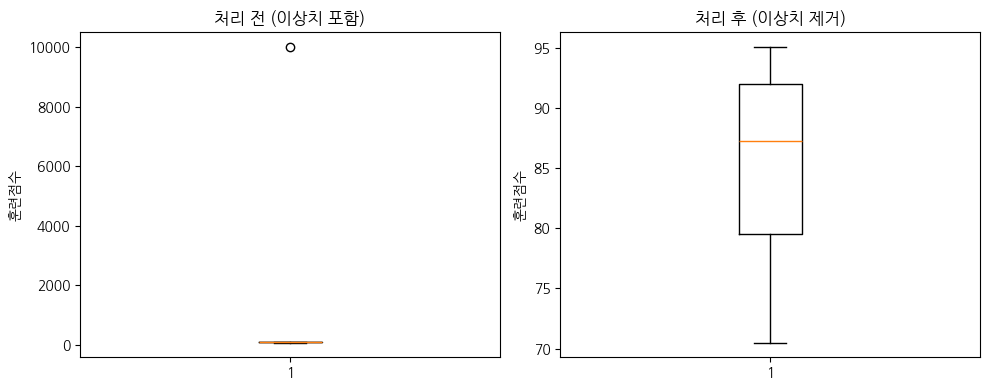

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 이상치 포함 (원본)
axes[0].boxplot(df['훈련점수'].dropna())
axes[0].set_title("처리 전 (이상치 포함)", fontsize=12)
axes[0].set_ylabel("훈련점수")

# 이상치 제거 후
axes[1].boxplot(df_clean['훈련점수'].dropna())
axes[1].set_title("처리 후 (이상치 제거)", fontsize=12)
axes[1].set_ylabel("훈련점수")

plt.tight_layout()
plt.show()

---
### 🔥 실습문제 7
`"급여"` 컬럼에서 **IQR 방법**으로 이상치를 탐지하고 처리하세요.

1. 결측값을 평균값으로 먼저 채우기
2. Q1, Q3, IQR 계산
3. 이상치의 상·하한선 출력
4. 이상치 **개수** 확인
5. 이상치를 **제거한** 새 DataFrame 생성

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 1) 결측값 평균으로 채우기
df['급여'] = df['급여'].fillna(df['급여'].mean())

# 2) IQR 계산
col = '급여'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 3) 범위 출력
print(f"Q1 = {Q1:.1f}, Q3 = {Q3:.1f}, IQR = {IQR:.1f}")
print(f"정상 범위: [{lower:.1f}, {upper:.1f}]")

# 4) 이상치 개수
out_mask = (df[col] < lower) | (df[col] > upper)
print(f"이상치 개수: {out_mask.sum()}개")
if out_mask.sum() > 0:
    print(df[out_mask][['이름', '급여']])

# 5) 이상치 제거
df_clean = df[~out_mask].reset_index(drop=True)
print(f"\n제거 후: {df.shape[0]} → {df_clean.shape[0]}행")

---
# 📈 Chapter 8. 데이터 그룹화 & 집계 — `groupby`

> 실무에서 **가장 자주 쓰는** 분석: 부서별 평균, 월별 합계, 계급별 통계 등

## 8-1. GroupBy 동작 원리: Split → Apply → Combine

```
   ✂️ Split          ⚙️ Apply        🔗 Combine
   ─────────         ────────       ──────────
   그룹 기준으로  →  각 그룹에    →  결과를 합쳐
   데이터 분리       집계 함수 적용    새 DataFrame 생성
```

In [ ]:
# 실습용 깨끗한 데이터 준비
df = pd.read_csv('/content/soldiers.csv')
df['급여'] = df['급여'].fillna(df['급여'].mean())
df['훈련점수'] = df['훈련점수'].replace(9999, np.nan).fillna(df['훈련점수'][df['훈련점수']<1000].mean())
df['출석률'] = df['출석률'].fillna(df['출석률'].median())
df = df.drop_duplicates(subset=['이름'])
df.head(3)

## 8-2. 단일 컬럼 집계

In [63]:
# 부서별 평균 급여
print("[ 부서별 평균 급여 ]")
print(df.groupby('부서')['급여'].mean().round(1))

# 부서별 인원 수
print("\n[ 부서별 인원 수 ]")
print(df.groupby('부서').size())

# 계급별 평균 훈련점수
print("\n[ 계급별 평균 훈련점수 ]")
print(df.groupby('계급')['훈련점수'].mean().round(2))

[ 부서별 평균 급여 ]
부서
보급과    372.5
통신과    380.0
행정과    404.2
Name: 급여, dtype: float64

[ 부서별 인원 수 ]
부서
보급과    6
통신과    7
행정과    7
dtype: int64

[ 계급별 평균 훈련점수 ]
계급
병장      91.96
상병      88.14
이병    2059.02
일병      84.30
Name: 훈련점수, dtype: float64


## 8-3. 여러 집계 함수 동시 적용 — `agg()`

In [64]:
# 방법 1: 리스트로 여러 함수
result1 = df.groupby('부서')['급여'].agg(['mean', 'max', 'min', 'count'])
print("[ 부서별 급여 통계 ]")
print(result1.round(1))

[ 부서별 급여 통계 ]
      mean    max    min  count
부서                             
보급과  372.5  480.0  260.0      6
통신과  380.0  475.0  255.0      6
행정과  404.2  470.0  250.0      6


In [65]:
# 방법 2: 컬럼별로 다른 함수 지정
result2 = df.groupby('부서').agg({
    '급여': 'mean',
    '훈련점수': ['mean', 'max'],
    '출석률': 'mean'
}).round(2)

print("[ 부서별 다중 집계 ]")
print(result2)

[ 부서별 다중 집계 ]
         급여     훈련점수            출석률
       mean     mean     max   mean
부서                                 
보급과  372.50    84.88    94.3  87.70
통신과  380.00  1739.42  9999.0  82.86
행정과  404.17    83.86    95.1  90.60


In [ ]:
# 방법 3: 가독성 좋게 컬럼명 직접 지정
result3 = df.groupby('부서').agg(
    평균급여    = ('급여', 'mean'),
    최대점수    = ('훈련점수', 'max'),
    평균출석률  = ('출석률', 'mean'),
    인원수      = ('이름', 'count')
).round(1).reset_index()

print("[ 이름 지정 집계 (가독성 good) ]")
print(result3)

## 8-4. 다중 그룹 기준

In [66]:
# 부서 + 계급별 평균 급여
multi = df.groupby(['부서', '계급'])['급여'].mean().round(1)
print("[ 부서 × 계급별 평균 급여 ]")
print(multi)

[ 부서 × 계급별 평균 급여 ]
부서   계급
보급과  병장    430.0
     상병    410.0
     이병    260.0
     일병    352.5
통신과  병장    418.3
     상병    430.0
     이병    255.0
     일병    340.0
행정과  병장    470.0
     상병    418.3
     이병    250.0
     일병    450.0
Name: 급여, dtype: float64


## 8-5. 피벗 테이블 (Pivot Table) — 엑셀 스타일

In [67]:
pivot = df.pivot_table(
    index='부서',       # 행
    columns='계급',      # 열
    values='훈련점수',   # 집계 대상
    aggfunc='mean'       # 집계 함수
).round(2)

print("[ 피벗 테이블: 부서 × 계급별 평균 훈련점수 ]")
print(pivot)

[ 피벗 테이블: 부서 × 계급별 평균 훈련점수 ]
계급     병장     상병       이병     일병
부서                              
보급과  93.3  88.00    75.00  79.85
통신과  92.7  91.20  5038.75  82.40
행정과  87.8  87.17    71.30  95.10


In [70]:
!git clone https://github.com/KimJong-sub/shrek.git

Cloning into 'shrek'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 283.34 KiB | 13.49 MiB/s, done.


## 8-6. 그룹별 집계 결과 시각화

In [ ]:
# 부서별 평균 급여 막대그래프
dept_pay = df.groupby('부서')['급여'].mean().round(1)

plt.figure(figsize=(8, 4))
bars = plt.bar(dept_pay.index, dept_pay.values,
               color=['#2E86AB', '#5BA3C7', '#A7CFE0'], edgecolor='black')

for bar, v in zip(bars, dept_pay.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{v:.1f}', ha='center', fontweight='bold')

plt.title("부서별 평균 급여", fontsize=14, fontweight='bold')
plt.ylabel("평균 급여 (만원)")
plt.ylim(0, max(dept_pay.values) * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
### 🔥 실습문제 8
`df` 데이터에 대해 다음을 수행하세요.

1. **계급별** 평균 급여, 평균 훈련점수, 인원수를 한 번에 출력
2. **부서별** 훈련점수의 **최대값**과 **최소값** 을 계산하여 표로 출력
3. **입사연도별** 평균 출석률 계산 (연도 오름차순 정렬)
4. **피벗 테이블**: 부서(행) × 계급(열)의 **평균 출석률** 생성

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 계급별 종합 집계
print("[ 1. 계급별 종합 통계 ]")
result1 = df.groupby('계급').agg(
    평균급여   = ('급여', 'mean'),
    평균점수   = ('훈련점수', 'mean'),
    인원수     = ('이름', 'count')
).round(2)
print(result1)

# 2) 부서별 훈련점수 max/min
print("\n[ 2. 부서별 훈련점수 범위 ]")
result2 = df.groupby('부서')['훈련점수'].agg(['max', 'min']).round(2)
print(result2)

# 3) 입사연도별 평균 출석률
print("\n[ 3. 입사연도별 평균 출석률 ]")
result3 = df.groupby('입사연도')['출석률'].mean().round(2).sort_index()
print(result3)

# 4) 피벗 테이블
print("\n[ 4. 부서 × 계급 피벗 - 평균 출석률 ]")
pivot = df.pivot_table(
    index='부서', columns='계급',
    values='출석률', aggfunc='mean'
).round(2)
print(pivot)

---
# 🏆 종합 실습 프로젝트 — 데이터 전처리 파이프라인

> 🎯 **목표**: 원본 데이터를 불러와 **결측값 → 중복 → 타입 변환 → 이상치 → 정규화 → 집계** 까지  
> 완결된 **전처리 파이프라인**을 구축합니다.

## 요구사항 체크리스트

- [ ] ① 원본 CSV 불러오기 + shape 확인
- [ ] ② 결측값 확인 및 처리 (급여·훈련점수·출석률)
- [ ] ③ 중복 행 제거 (이름 기준)
- [ ] ④ 타입 변환 (입대일 → datetime)
- [ ] ⑤ 이상치 제거 (훈련점수 IQR 방법)
- [ ] ⑥ 정규화 (급여 Min-Max)
- [ ] ⑦ 그룹 집계 (부서별 평균)
- [ ] ⑧ 시각화 (막대그래프 + 박스플롯)
- [ ] ⑨ 정제된 데이터 저장

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("=" * 50)
print("🚀 데이터 전처리 파이프라인 시작")
print("=" * 50)

# ────────────────────────────────
# ① 데이터 불러오기
# ────────────────────────────────
df = pd.read_csv('/content/soldiers.csv')
print(f"\n① 원본: {df.shape[0]}행 × {df.shape[1]}열")

# ────────────────────────────────
# ② 결측값 처리
# ────────────────────────────────
print(f"\n② 결측값 처리 전:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['급여']     = df['급여'].fillna(df['급여'].mean())
df['훈련점수'] = df['훈련점수'].fillna(df['훈련점수'].median())
df['출석률']   = df['출석률'].fillna(df['출석률'].median())

print(f"\n   ✅ 결측값 처리 후: {df.isnull().sum().sum()}개")

# ────────────────────────────────
# ③ 중복 제거
# ────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['이름'], keep='first').reset_index(drop=True)
print(f"\n③ 중복 제거: {before} → {len(df)}행 ({before-len(df)}개 제거)")

# ────────────────────────────────
# ④ 타입 변환
# ────────────────────────────────
df['입대일'] = pd.to_datetime(df['입대일'])
df['입대연도'] = df['입대일'].dt.year
print(f"\n④ 타입 변환 완료 (입대일 → datetime)")

# ────────────────────────────────
# ⑤ 이상치 제거 (IQR)
# ────────────────────────────────
col = '훈련점수'
Q1, Q3 = df[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

out_mask = (df[col] < lower) | (df[col] > upper)
print(f"\n⑤ 이상치 탐지: {out_mask.sum()}개")
df = df[~out_mask].reset_index(drop=True)
print(f"   제거 후: {len(df)}행")

# ────────────────────────────────
# ⑥ 정규화
# ────────────────────────────────
mm = MinMaxScaler()
df['급여_정규화'] = mm.fit_transform(df[['급여']]).round(3)
print(f"\n⑥ 급여 정규화 완료 [0, 1] 범위로 변환")

# ────────────────────────────────
# ⑦ 집계
# ────────────────────────────────
print(f"\n⑦ 부서별 요약 통계:")
summary = df.groupby('부서').agg(
    인원수    = ('이름', 'count'),
    평균급여  = ('급여', 'mean'),
    평균점수  = ('훈련점수', 'mean'),
    평균출석  = ('출석률', 'mean')
).round(2)
print(summary)

# ────────────────────────────────
# ⑨ 정제 데이터 저장
# ────────────────────────────────
df.to_csv('/content/soldiers_clean.csv', index=False, encoding='utf-8-sig')
print(f"\n⑨ 저장 완료: /content/soldiers_clean.csv")
print(f"   최종: {df.shape[0]}행 × {df.shape[1]}열")
print("=" * 50)

In [ ]:
# ⑧ 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 부서별 평균 급여 막대그래프
dept_pay = df.groupby('부서')['급여'].mean().round(1)
bars = axes[0].bar(dept_pay.index, dept_pay.values,
                   color=['#2E86AB', '#5BA3C7', '#A7CFE0'], edgecolor='black')
for bar, v in zip(bars, dept_pay.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{v:.1f}', ha='center', fontweight='bold')
axes[0].set_title("부서별 평균 급여", fontsize=13, fontweight='bold')
axes[0].set_ylabel("급여 (만원)")
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 부서별 훈련점수 박스플롯
dept_list = df['부서'].unique()
data_list = [df[df['부서']==d]['훈련점수'].values for d in dept_list]
axes[1].boxplot(data_list, labels=dept_list)
axes[1].set_title("부서별 훈련점수 분포", fontsize=13, fontweight='bold')
axes[1].set_ylabel("훈련점수")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ 전처리 파이프라인 완료! 다음 단계는 3일차 EDA·시각화입니다.")

---
### 🔥 최종 도전 과제
위 파이프라인을 확장하여 다음을 추가해 보세요.

1. **`"복무기간(일수)"`** 컬럼 추가 → 오늘 날짜 - 입대일
2. **계급 코드** 컬럼 추가 (이병=1, 일병=2, 상병=3, 병장=4)
3. **원-핫 인코딩** 적용 → `pd.get_dummies(columns=['부서'])`
4. **종합 점수** 컬럼 추가 → (훈련점수 × 0.6 + 출석률 × 0.4)
5. **종합 점수 상위 5명** 출력

💡 어려우면 ChatGPT/Claude에 Vibe Coding으로 요청하세요!

In [ ]:
# ✍️ 여기에 도전 과제 코드를 작성하세요



**✅ 도전 과제 정답 예시**

In [ ]:
from datetime import datetime

# 원본 정제된 데이터 다시 불러오기
df = pd.read_csv('/content/soldiers_clean.csv')
df['입대일'] = pd.to_datetime(df['입대일'])

# 1) 복무기간(일수)
today = pd.Timestamp.today().normalize()
df['복무기간일'] = (today - df['입대일']).dt.days

# 2) 계급 코드
rank_map = {'이병': 1, '일병': 2, '상병': 3, '병장': 4}
df['계급코드'] = df['계급'].map(rank_map)

# 3) 원-핫 인코딩 (부서)
df_encoded = pd.get_dummies(df, columns=['부서'], prefix='부서')

# 4) 종합 점수
df['종합점수'] = (df['훈련점수'] * 0.6 + df['출석률'] * 0.4).round(2)

# 5) 상위 5명
top5 = df.sort_values('종합점수', ascending=False).head(5)
print("🏆 종합점수 TOP 5")
print(top5[['이름', '계급', '부서', '훈련점수', '출석률', '종합점수']].to_string(index=False))

print("\n[ 원-핫 인코딩 결과 (앞 5행) ]")
print(df_encoded.head().to_string())

---
# 🎓 2일차 학습 정리

## ✅ 오늘 배운 내용

| 챕터 | 핵심 내용 | 주요 함수 |
|---|---|---|
| **1. 데이터 수집** | 공공데이터·API·파일 | `requests.get()` |
| **2. 파일 읽기** | CSV·Excel·JSON | `pd.read_csv/excel/json()` |
| **3. 데이터 탐색** | 구조·통계 파악 | `head/info/describe/shape` |
| **4. 선택·필터링** | 라벨/위치/조건 | `loc/iloc`, Boolean Indexing |
| **5. 결측값 처리** | 삭제·채우기 | `isnull/dropna/fillna` |
| **6. 타입·정규화** | 변환·스케일링 | `astype/MinMaxScaler` |
| **7. 이상치 처리** | IQR·제거·대체 | `quantile/clip` |
| **8. 그룹화·집계** | split-apply-combine | `groupby/agg/pivot_table` |

## 🔄 전처리 표준 파이프라인
```
수집 → 탐색 → 결측값 처리 → 중복 제거 → 타입 변환 →
이상치 제거 → 정규화 → 분석 준비 완료 🚀
```

## 📅 다음 일정
- **3일차**: 데이터 분석 및 가공 (그룹화 심화·피벗·상관분석·시각화)
- **4일차**: 미니 프로젝트 — 부대 실무 데이터 EDA

---
**스마트 강군 육성, 국방 AX(AI 전환)에 만전을 기하겠습니다** 🎖️

*교육기관: (사)한국오픈소스협회 | 문의: 02-6012-7414 / kmil@osskorea.org*